# Notebook 19 - Exercise 4: Automatically Discovered Non-Parametric Predictive Structure

Notebook 19 repeats Linus's three empirical steps for Random Forest, Gradient Boosting, MLP, and Transformer models.

1. **Discover** each model's nonlinear predictive parent blocks and lag order on TRAIN → VALIDATION common support.
2. **Freeze and forecast** with independently selected hyperparameters, then evaluate TEST once.
3. **Refit eventless backgrounds** with the discovered specification unchanged and estimate event weights using corrected Notebook 18 timing.

“Structure” means conditional predictive or Granger-style structure: whether a lagged source improves out-of-sample prediction conditional on retained histories. It is not structural economic causality. Transformer attention masking prevents use of future tokens; attention weights are not treated as causal edges.

## 19.0 Scope, conventions, and leakage contract

The maximum lag of 12 is a search ceiling, not a supplied final order. All lags are constructed on the intact chronology before any split filter or event mask. TEST is excluded from every selection decision, N16 results are loaded only after structures freeze, and N18 event masks enter only in Step 3.

In [2]:
from pathlib import Path
from copy import deepcopy
import json
import math
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

pd.set_option("display.max_columns", 120)
warnings.filterwarnings("ignore", message="enable_nested_tensor")
torch.set_num_threads(1)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

ROOT = next(parent for parent in [Path.cwd(), *Path.cwd().parents] if (parent / "Data" / "processed").exists())
PROCESSED = ROOT / "Data" / "processed"
FIGURES = ROOT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
RUN_ID = pd.Timestamp.now(tz="UTC").isoformat()

L_MAX = 12
STATES = ("Q", "R", "I")
TARGETS = ("R", "I")
MODEL_FAMILIES = ("RF", "GB", "MLP", "TRANSFORMER")
FAMILIES = ("FOMC", "US Employment", "US CPI", "BoJ", "JPY National CPI", "JPY GDP")
SEEDS = (19, 119, 219)
MAX_EPOCHS = 400
PATIENCE = 40
MIN_DELTA = 1e-5
BATCH_SIZE = 64
PARSIMONY_BAND = 1.01
INLINE_FIGURE_DISPLAY_COUNT = 0
TREE_FEATURE_NAME_AUDIT_COUNT = 0

# Canonical timing-propagation mode: reuse pre-TEST specifications, never fitted estimators.
REUSE_FROZEN_SELECTION = True
FROZEN_SELECTED_CONFIGURATIONS = {
    ("RF", "R"): "RF_01", ("GB", "R"): "GB_02",
    ("MLP", "R"): "MLP_04", ("TRANSFORMER", "R"): "TR_01",
    ("RF", "I"): "RF_01", ("GB", "I"): "GB_02",
    ("MLP", "I"): "MLP_03", ("TRANSFORMER", "I"): "TR_03",
}
FROZEN_FIXED_EPOCHS = {("MLP", "R"): 143, ("TRANSFORMER", "R"): 52, ("MLP", "I"): 77, ("TRANSFORMER", "I"): 19}
assert set(FROZEN_SELECTED_CONFIGURATIONS) == {(model, target) for model in MODEL_FAMILIES for target in TARGETS}

# Frozen upstream production-domain floors; target-support constants, not model parameters.
FROZEN_TARGET_FLOORS = {"R": 0.0003202993332501, "I": 0.0015767239436135}

def admissible_forecast(raw_forecast, target):
    return np.maximum(np.asarray(raw_forecast, dtype=float), FROZEN_TARGET_FLOORS[target])


SPLIT_BOUNDS = {
    "train": (pd.Timestamp("2003-05-05"), pd.Timestamp("2017-03-27")),
    "validation": (pd.Timestamp("2017-03-28"), pd.Timestamp("2021-11-12")),
    "test": (pd.Timestamp("2021-11-15"), pd.Timestamp("2026-07-02")),
}

panel = pd.read_csv(PROCESSED / "16_empirical_analysis_panel.csv", parse_dates=["model_day"])
panel = panel.sort_values("model_day").reset_index(drop=True)
panel["Q"] = pd.to_numeric(panel["squared_return"])
panel["R"] = pd.to_numeric(panel["realised_variance_ann_252"])
panel["I"] = pd.to_numeric(panel["iv_model_var"])
assert panel["model_day"].is_unique and panel["model_day"].is_monotonic_increasing
for split, (start, end) in SPLIT_BOUNDS.items():
    observed = panel.loc[panel["sample_split"].eq(split), "model_day"]
    assert observed.min() == start and observed.max() == end

selection_audit = {
    "structure_selection_split": "TRAIN_TO_VALIDATION",
    "hyperparameter_selection_split": "TRAIN_TO_VALIDATION",
    "test_used_for_selection": False,
    "n16_structure_used_for_selection": False,
    "event_mask_used_for_structure_selection": False,
    "event_mask_used_for_hyperparameter_selection": False,
    "l_max": L_MAX,
    "lag_order_is_data_selected": True,
}
scope_audit = pd.DataFrame([
    ("Targets", "R, I"),
    ("Models", ", ".join(MODEL_FAMILIES)),
    ("TRAIN / VALIDATION / TEST N", " / ".join(str(int(panel["sample_split"].eq(s).sum())) for s in ["train", "validation", "test"])),
    ("Maximum candidate lag", "12 (search ceiling)"),
    ("R parent candidates", "{R}, {R,Q}, {R,I}, {R,Q,I}"),
    ("I parent candidates", "{I}, {I,Q}, {I,R}, {I,Q,R}"),
    ("Eventless timing source", "Corrected N18 family-specific pre-announcement contract, loaded only in Step 3"),
    ("Frozen-selection reuse", str(REUSE_FROZEN_SELECTION)),
    ("Leakage rule", "TRAIN fits; VALIDATION selects; TEST evaluated once"),
], columns=["Audit item", "Frozen convention"])
display(scope_audit)
print("Execution device:", DEVICE)

,Audit item,Frozen convention
0,Targets,"R, I"
1,Models,"RF, GB, MLP, TRANSFORMER"
2,TRAIN / VALIDATION / TEST N,3626 / 1209 / 1209
3,Maximum candidate lag,12 (search ceiling)
4,R parent candidates,"{R}, {R,Q}, {R,I}, {R,Q,I}"
5,I parent candidates,"{I}, {I,Q}, {I,R}, {I,Q,R}"
6,Eventless timing source,Corrected N18 family-specific pre-announcement...
7,Frozen-selection reuse,True
8,Leakage rule,TRAIN fits; VALIDATION selects; TEST evaluated...


Execution device: cuda


## 19.1 Common data and structure-search support

The full Q, R, and I lag panel is built first. Candidate structures for a given target are then compared on identical TRAIN and VALIDATION rows requiring the target and every lag 1–12 of all three states to be finite. No event mask is present in this stage.

In [3]:
state_snapshot = panel[["model_day", "Q", "R", "I"]].copy()
MAX_LAG_FEATURES = [f"{state}_lag{lag}" for state in STATES for lag in range(1, L_MAX + 1)]
for state in STATES:
    for lag in range(1, L_MAX + 1):
        panel[f"{state}_lag{lag}"] = panel[state].shift(lag)
lag_snapshot = panel[["model_day", *MAX_LAG_FEATURES]].copy()
assert panel[["model_day", "Q", "R", "I"]].equals(state_snapshot)
assert L_MAX == 12

PARENT_SETS = {
    "R": (("R",), ("R", "Q"), ("R", "I"), ("R", "Q", "I")),
    "I": (("I",), ("I", "Q"), ("I", "R"), ("I", "Q", "R")),
}
SEARCH_SUPPORT = {}
support_rows = []
for target in TARGETS:
    finite = np.isfinite(panel[[target, *MAX_LAG_FEATURES]].to_numpy(dtype=float)).all(axis=1)
    for split in ("train", "validation"):
        frame = panel.loc[finite & panel["sample_split"].eq(split)].copy()
        SEARCH_SUPPORT[(target, split)] = frame
        support_rows.append({
            "target": target,
            "split": split,
            "raw_split_n": int(panel["sample_split"].eq(split).sum()),
            "common_structure_support_n": len(frame),
            "finite_target_required": True,
            "finite_all_QRI_lags_1_12_required": True,
            "event_mask_applied": False,
            "lags_built_before_split_filter": True,
            "selection_support_evaluated": True,
        })
    support_rows.append({
        "target": target,
        "split": "test",
        "raw_split_n": int(panel["sample_split"].eq("test").sum()),
        "common_structure_support_n": np.nan,
        "finite_target_required": False,
        "finite_all_QRI_lags_1_12_required": False,
        "event_mask_applied": False,
        "lags_built_before_split_filter": True,
        "selection_support_evaluated": False,
    })
input_and_support_audit = pd.DataFrame(support_rows)
assert not any(column.startswith(("R_is_", "I_is_")) for column in panel.columns)
assert not input_and_support_audit.loc[input_and_support_audit["split"].eq("test"), "selection_support_evaluated"].any()
display(input_and_support_audit)

,target,split,raw_split_n,common_structure_support_n,finite_target_required,finite_all_QRI_lags_1_12_required,event_mask_applied,lags_built_before_split_filter,selection_support_evaluated
0,R,train,3626,2200.0,True,True,False,True,True
1,R,validation,1209,1078.0,True,True,False,True,True
2,R,test,1209,NaN,False,False,False,True,False
3,I,train,3626,2226.0,True,True,False,True,True
4,I,validation,1209,1087.0,True,True,False,True,True
5,I,test,1209,NaN,False,False,False,True,False


## 19.2 Step 1 — automatic nonlinear predictive-structure discovery

For each model and target, 48 candidates are evaluated: four parent-block sets crossed with lag orders 1–12. RF and GB use the first grid configuration as a deterministic probe. MLP and Transformer use their first configuration under all three frozen seeds; mean VALIDATION RMSE selects structure. TEST, N16 structure results, and event masks are unavailable to this code.

The pre-frozen parsimony rule selects the fewest cross-series blocks and then the shortest lag inside 1% of the minimum VALIDATION RMSE.

**EXPENSIVE MODEL-SELECTION BLOCK. DO NOT EXECUTE WHEN `REUSE_FROZEN_SELECTION=True`.** Frozen model specifications are reused; fitted RF trees, GB estimators, neural-network weights and scalers are not reused when the eventless calibration sample changes.

In [4]:
RF_GRID = {
    "RF_01": {"max_depth": 8, "min_samples_leaf": 5},
    "RF_02": {"max_depth": 8, "min_samples_leaf": 10},
    "RF_03": {"max_depth": None, "min_samples_leaf": 5},
    "RF_04": {"max_depth": None, "min_samples_leaf": 10},
}
GB_GRID = {
    "GB_01": {"n_estimators": 200, "learning_rate": 0.03},
    "GB_02": {"n_estimators": 200, "learning_rate": 0.05},
    "GB_03": {"n_estimators": 400, "learning_rate": 0.03},
    "GB_04": {"n_estimators": 400, "learning_rate": 0.05},
}
MLP_GRID = {
    "MLP_01": ([32], 1e-3),
    "MLP_02": ([32], 3e-4),
    "MLP_03": ([32, 16], 1e-3),
    "MLP_04": ([32, 16], 3e-4),
}
TR_GRID = {
    "TR_01": ((16, 2, 32), 1e-3),
    "TR_02": ((16, 2, 32), 3e-4),
    "TR_03": ((24, 4, 48), 1e-3),
    "TR_04": ((24, 4, 48), 3e-4),
}
GRIDS = {"RF": RF_GRID, "GB": GB_GRID, "MLP": MLP_GRID, "TRANSFORMER": TR_GRID}
PROBE_CONFIG = {model: next(iter(GRIDS[model])) for model in MODEL_FAMILIES}
RF_FIXED = {
    "n_estimators": 500, "max_features": 0.5, "criterion": "squared_error",
    "bootstrap": True, "random_state": 19, "n_jobs": -1,
}
GB_FIXED = {
    "max_depth": 2, "min_samples_leaf": 10, "subsample": 1.0,
    "loss": "squared_error", "random_state": 19,
}
probe_configuration_table = pd.DataFrame([
    {"model": model, "probe_candidate_id": config_id, "probe_hyperparameters": str(GRIDS[model][config_id])}
    for model, config_id in PROBE_CONFIG.items()
])
display(probe_configuration_table)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def feature_columns(parents, lag_order):
    return [f"{state}_lag{lag}" for lag in range(lag_order, 0, -1) for state in parents]

def model_frame(target, split, parents, lag_order, common_support=False):
    if common_support:
        return SEARCH_SUPPORT[(target, split)].copy()
    columns = [target, *feature_columns(parents, lag_order)]
    finite = np.isfinite(panel[columns].to_numpy(dtype=float)).all(axis=1)
    return panel.loc[finite & panel["sample_split"].eq(split)].copy()

def compute_metrics(actual, prediction, persistence=None):
    actual = np.asarray(actual, dtype=float)
    prediction = np.asarray(prediction, dtype=float)
    valid = np.isfinite(actual) & np.isfinite(prediction)
    actual = actual[valid]
    prediction = prediction[valid]
    error = actual - prediction
    positive = (actual > 0) & (prediction > 0)
    qlike = np.nan
    if positive.any():
        ratio = actual[positive] / prediction[positive]
        qlike = float(np.mean(ratio - np.log(ratio) - 1))
    oos_r2 = np.nan
    if persistence is not None:
        persistence = np.asarray(persistence, dtype=float)[valid]
        paired = np.isfinite(persistence)
        denominator = np.sum((actual[paired] - persistence[paired]) ** 2)
        if denominator > 0:
            oos_r2 = float(1 - np.sum((actual[paired] - prediction[paired]) ** 2) / denominator)
    return {
        "valid_forecast_n": int(len(actual)),
        "RMSE": float(np.sqrt(np.mean(error ** 2))),
        "MAE": float(np.mean(np.abs(error))),
        "QLIKE": qlike,
        "QLIKE_valid_n": int(positive.sum()),
        "OOS_R2": oos_r2,
        "nonpositive_forecast_n": int((prediction <= 0).sum()),
    }

def make_tree(model, config_id):
    if model == "RF":
        return RandomForestRegressor(**RF_FIXED, **RF_GRID[config_id])
    return GradientBoostingRegressor(**GB_FIXED, **GB_GRID[config_id])

def fit_scaler(frame, target, parents, lag_order):
    scale = {}
    for state in parents:
        columns = [f"{state}_lag{lag}" for lag in range(1, lag_order + 1)]
        values = frame[columns].to_numpy(dtype=float).ravel()
        std = float(values.std())
        assert std > 0
        scale[state] = (float(values.mean()), std)
    target_values = frame[target].to_numpy(dtype=float)
    target_std = float(target_values.std())
    assert target_std > 0
    scale["TARGET"] = (float(target_values.mean()), target_std)
    return scale

def scaled_features(frame, columns, scale):
    values = frame[columns].to_numpy(dtype=float).copy()
    for index, column in enumerate(columns):
        state = column.split("_lag")[0]
        mean, std = scale[state]
        values[:, index] = (values[:, index] - mean) / std
    return values

def scaled_feature_array(values, columns, scale):
    values = np.asarray(values, dtype=float).copy()
    for index, column in enumerate(columns):
        state = column.split("_lag")[0]
        mean, std = scale[state]
        values[:, index] = (values[:, index] - mean) / std
    return values

def scale_target(values, scale):
    mean, std = scale["TARGET"]
    return (np.asarray(values, dtype=float) - mean) / std

def unscale_target(values, scale):
    mean, std = scale["TARGET"]
    return np.asarray(values, dtype=float) * std + mean

class MLPRegressor(nn.Module):
    def __init__(self, input_width, hidden_layers):
        super().__init__()
        layers = []
        width = input_width
        for hidden in hidden_layers:
            layers.extend([nn.Linear(width, hidden), nn.ReLU(), nn.Dropout(0.1)])
            width = hidden
        layers.append(nn.Linear(width, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, inputs):
        return self.network(inputs).squeeze(-1)

class TransformerRegressor(nn.Module):
    def __init__(self, input_dimension, sequence_length, d_model, n_heads, ff_dim):
        super().__init__()
        self.embedding = nn.Linear(input_dimension, d_model)
        positions = torch.arange(sequence_length).unsqueeze(1)
        divisors = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        encoding = torch.zeros(sequence_length, d_model)
        encoding[:, 0::2] = torch.sin(positions * divisors)
        encoding[:, 1::2] = torch.cos(positions * divisors)
        self.register_buffer("positional_encoding", encoding.unsqueeze(0))
        no_future_mask = torch.triu(torch.ones(sequence_length, sequence_length, dtype=torch.bool), diagonal=1)
        self.register_buffer("no_future_mask", no_future_mask)
        layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=ff_dim,
            dropout=0.1, activation="gelu", batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=1)
        self.head = nn.Linear(d_model, 1)

    def forward(self, inputs):
        hidden = self.encoder(self.embedding(inputs) + self.positional_encoding, mask=self.no_future_mask)
        return self.head(hidden[:, -1]).squeeze(-1)

def make_neural(model, config_id, input_width, parent_count, lag_order):
    configuration = GRIDS[model][config_id]
    architecture, learning_rate = configuration
    if model == "MLP":
        network = MLPRegressor(input_width, architecture)
    else:
        network = TransformerRegressor(parent_count, lag_order, *architecture)
    return network.to(DEVICE), learning_rate

def neural_tensor(values, model, lag_order, parent_count):
    tensor = torch.tensor(values, dtype=torch.float32)
    if model == "TRANSFORMER":
        tensor = tensor.reshape(-1, lag_order, parent_count)
    return tensor

def train_neural_early(model, config_id, seed, train_frame, validation_frame, target, parents, lag_order):
    set_seed(seed)
    columns = feature_columns(parents, lag_order)
    scale = fit_scaler(train_frame, target, parents, lag_order)
    train_x = neural_tensor(scaled_features(train_frame, columns, scale), model, lag_order, len(parents))
    train_y = torch.tensor(scale_target(train_frame[target], scale), dtype=torch.float32)
    validation_x = neural_tensor(scaled_features(validation_frame, columns, scale), model, lag_order, len(parents)).to(DEVICE)
    validation_y = torch.tensor(scale_target(validation_frame[target], scale), dtype=torch.float32).to(DEVICE)
    network, learning_rate = make_neural(model, config_id, len(columns), len(parents), lag_order)
    optimizer = torch.optim.AdamW(network.parameters(), lr=learning_rate, weight_decay=1e-4)
    loss_function = nn.MSELoss()
    loader = DataLoader(TensorDataset(train_x, train_y), batch_size=BATCH_SIZE, shuffle=True)
    best_loss, best_state, best_epoch, wait = float("inf"), None, 0, 0
    for epoch in range(1, MAX_EPOCHS + 1):
        network.train()
        for batch_x, batch_y in loader:
            batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_function(network(batch_x), batch_y)
            loss.backward()
            if model == "TRANSFORMER":
                torch.nn.utils.clip_grad_norm_(network.parameters(), max_norm=1.0)
            optimizer.step()
        network.eval()
        with torch.no_grad():
            validation_loss = loss_function(network(validation_x), validation_y).item()
        if validation_loss < best_loss - MIN_DELTA:
            best_loss = validation_loss
            best_state = {name: value.detach().clone() for name, value in network.state_dict().items()}
            best_epoch, wait = epoch, 0
        else:
            wait += 1
        if wait >= PATIENCE:
            break
    assert best_state is not None
    network.load_state_dict(best_state)
    return network, scale, best_epoch

def predict_neural(network, frame_or_array, columns, scale, model, lag_order, parent_count):
    if isinstance(frame_or_array, pd.DataFrame):
        values = scaled_features(frame_or_array, columns, scale)
    else:
        values = scaled_feature_array(frame_or_array, columns, scale)
    inputs = neural_tensor(values, model, lag_order, parent_count).to(DEVICE)
    network.eval()
    with torch.no_grad():
        prediction = network(inputs).detach().cpu().numpy()
    return unscale_target(prediction, scale)

def train_neural_fixed(model, config_id, seed, calibration, target, parents, lag_order, epochs):
    set_seed(seed)
    columns = feature_columns(parents, lag_order)
    scale = fit_scaler(calibration, target, parents, lag_order)
    train_x = neural_tensor(scaled_features(calibration, columns, scale), model, lag_order, len(parents))
    train_y = torch.tensor(scale_target(calibration[target], scale), dtype=torch.float32)
    network, learning_rate = make_neural(model, config_id, len(columns), len(parents), lag_order)
    optimizer = torch.optim.AdamW(network.parameters(), lr=learning_rate, weight_decay=1e-4)
    loss_function = nn.MSELoss()
    loader = DataLoader(TensorDataset(train_x, train_y), batch_size=BATCH_SIZE, shuffle=True)
    network.train()
    for _ in range(int(epochs)):
        for batch_x, batch_y in loader:
            batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_function(network(batch_x), batch_y)
            loss.backward()
            if model == "TRANSFORMER":
                torch.nn.utils.clip_grad_norm_(network.parameters(), max_norm=1.0)
            optimizer.step()
    return network, scale

def ensemble_prediction(models, frame_or_array, columns, scales, model, lag_order, parent_count):
    predictions = [
        predict_neural(network, frame_or_array, columns, scale, model, lag_order, parent_count)
        for network, scale in zip(models, scales)
    ]
    return np.mean(np.vstack(predictions), axis=0)

def save_figure(fig, filename):
    global INLINE_FIGURE_DISPLAY_COUNT
    assert filename.startswith("19_figure_") and filename.endswith(".png")
    FIGURES.mkdir(parents=True, exist_ok=True)
    path = FIGURES / filename
    if path.exists():
        assert path.is_file()
        path.unlink()
    display(fig)
    INLINE_FIGURE_DISPLAY_COUNT += 1
    fig.savefig(str(path), dpi=160, bbox_inches="tight")
    plt.close(fig)
    return path

,model,probe_candidate_id,probe_hyperparameters
0,RF,RF_01,"{'max_depth': 8, 'min_samples_leaf': 5}"
1,GB,GB_01,"{'n_estimators': 200, 'learning_rate': 0.03}"
2,MLP,MLP_01,"([32], 0.001)"
3,TRANSFORMER,TR_01,"((16, 2, 32), 0.001)"


In [5]:
structure_rows = []
neural_seed_records = pd.read_csv(PROCESSED / "19_neural_seed_diagnostics.csv").to_dict("records") if REUSE_FROZEN_SELECTION else []
for model in (() if REUSE_FROZEN_SELECTION else MODEL_FAMILIES):
    config_id = PROBE_CONFIG[model]
    for target in TARGETS:
        train_frame = SEARCH_SUPPORT[(target, "train")]
        validation_frame = SEARCH_SUPPORT[(target, "validation")]
        for parents in PARENT_SETS[target]:
            for lag_order in range(1, L_MAX + 1):
                columns = feature_columns(parents, lag_order)
                candidate_id = f"{target}__{'+'.join(parents)}__L{lag_order:02d}"
                if model in {"RF", "GB"}:
                    estimator = make_tree(model, config_id)
                    estimator.fit(train_frame[columns], train_frame[target])
                    prediction = estimator.predict(validation_frame[columns])
                    metric = compute_metrics(validation_frame[target], prediction)
                    seed_count = 1
                else:
                    seed_metrics = []
                    for seed in SEEDS:
                        network, scale, best_epoch = train_neural_early(
                            model, config_id, seed, train_frame, validation_frame,
                            target, parents, lag_order,
                        )
                        prediction = predict_neural(network, validation_frame, columns, scale, model, lag_order, len(parents))
                        metric_seed = compute_metrics(validation_frame[target], prediction)
                        neural_seed_records.append({
                            "stage": "STRUCTURE_SEARCH", "model": model, "target": target,
                            "candidate_id": candidate_id, "config_id": config_id, "seed": seed,
                            "parent_blocks": "|".join(parents), "lag_order": lag_order,
                            "best_epoch": best_epoch, "validation_RMSE": metric_seed["RMSE"],
                            "validation_MAE": metric_seed["MAE"],
                        })
                        seed_metrics.append(metric_seed)
                        del network
                    metric = {
                        "RMSE": float(np.mean([row["RMSE"] for row in seed_metrics])),
                        "MAE": float(np.mean([row["MAE"] for row in seed_metrics])),
                    }
                    seed_count = len(SEEDS)
                structure_rows.append({
                    "model": model, "target": target, "candidate_id": candidate_id,
                    "parent_blocks": "|".join(parents),
                    "parent_label": "{" + ",".join(parents) + "}",
                    "cross_parent_count": len(parents) - 1,
                    "lag_order": lag_order, "probe_config_id": config_id,
                    "validation_RMSE": metric["RMSE"], "validation_MAE": metric["MAE"],
                    "seed_count": seed_count,
                })
        print(f"Structure search complete: {model} target {target}")

structure_search_validation = pd.read_csv(PROCESSED / "19_structure_search_validation.csv") if REUSE_FROZEN_SELECTION else pd.DataFrame(structure_rows)
assert len(structure_search_validation) == 384
assert not structure_search_validation.duplicated(["model", "target", "candidate_id"]).any()
assert structure_search_validation["lag_order"].between(1, L_MAX).all()
assert selection_audit["test_used_for_selection"] is False
assert selection_audit["n16_structure_used_for_selection"] is False
assert selection_audit["event_mask_used_for_structure_selection"] is False

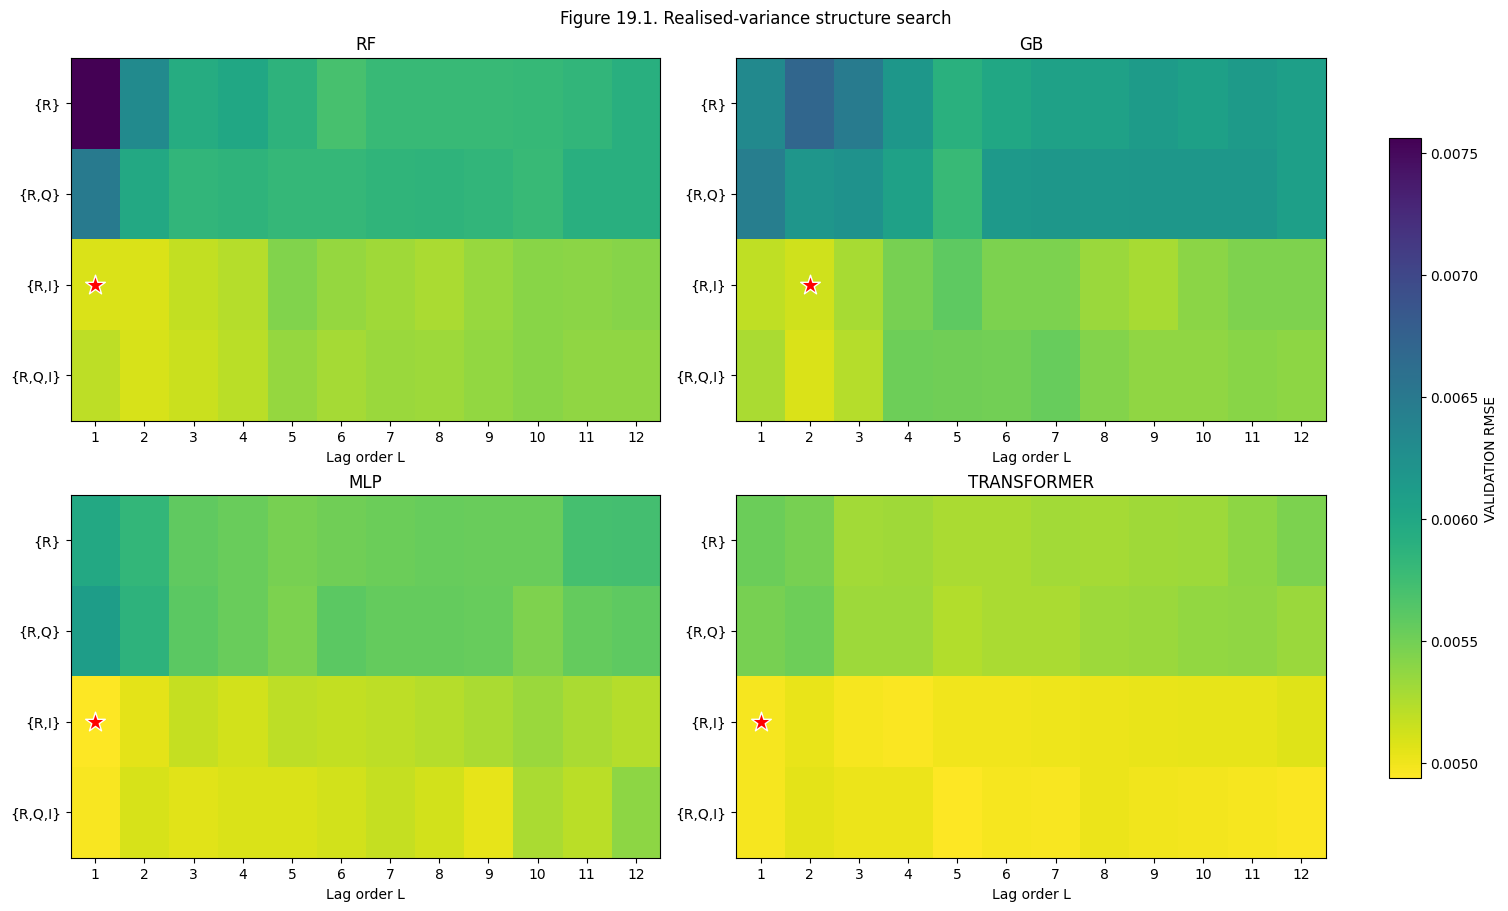

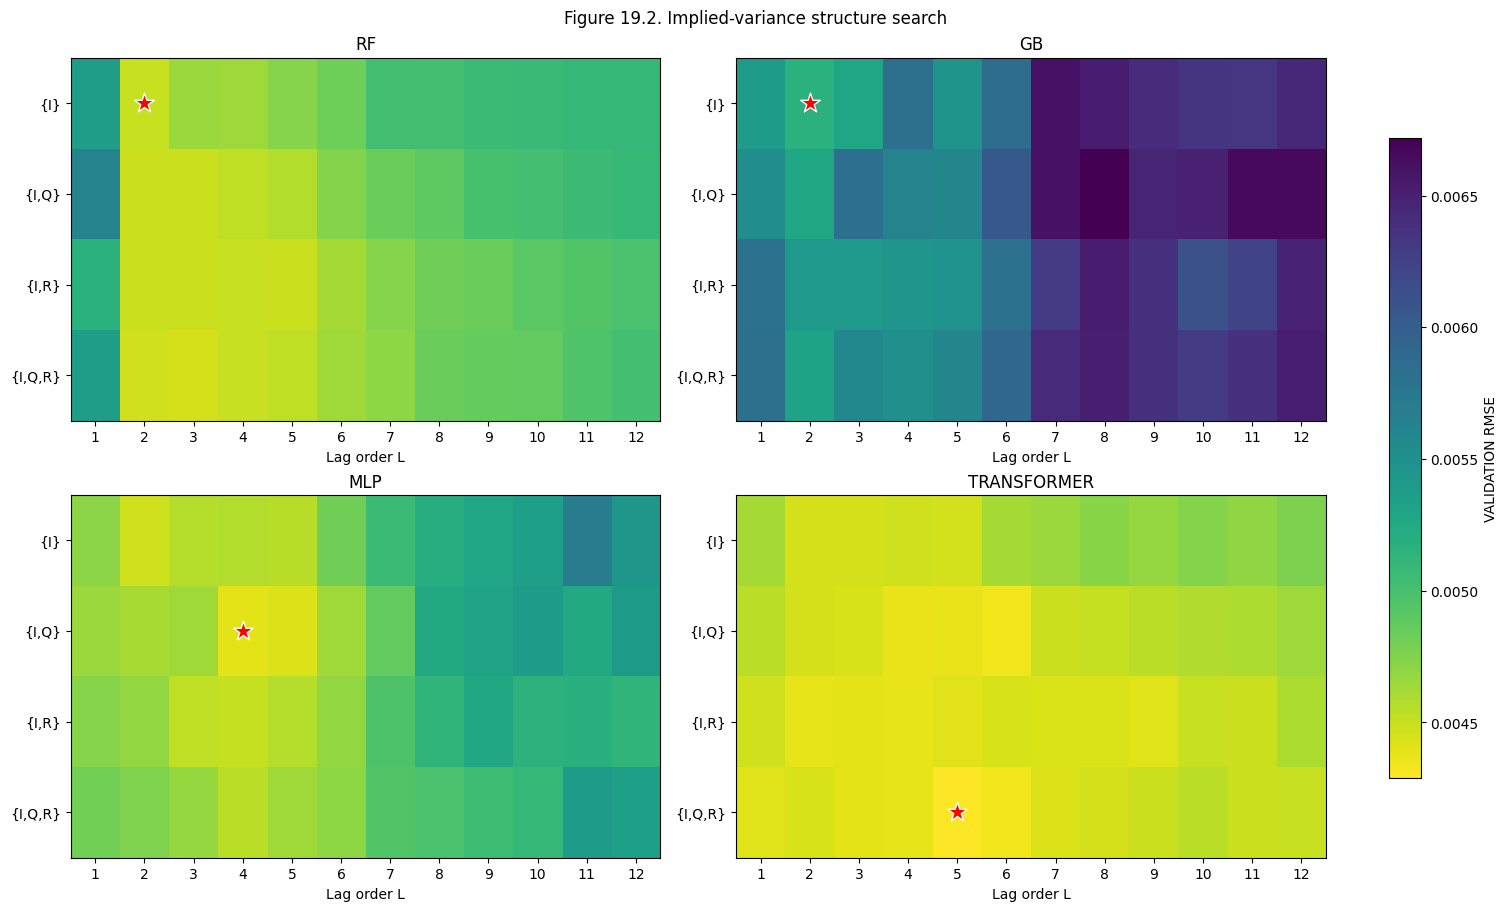

Table 19.2 — discovered structures


,model,target,selected_parent_label,selected_lag_order,minimum_validation_RMSE,selected_validation_RMSE,parsimony_changed_raw_winner
0,GB,I,{I},2,0.005172,0.005172,False
1,MLP,I,"{I,Q}",4,0.004388,0.004388,False
2,RF,I,{I},2,0.004449,0.004490,True
3,TRANSFORMER,I,"{I,Q,R}",5,0.004290,0.004290,False
4,GB,R,"{R,I}",2,0.005086,0.005134,True
5,MLP,R,"{R,I}",1,0.004942,0.004942,False
6,RF,R,"{R,I}",1,0.005085,0.005089,True
7,TRANSFORMER,R,"{R,I}",1,0.004940,0.004978,True


In [6]:
structure_search_validation["within_1pct"] = False
structure_search_validation["raw_rmse_winner"] = False
structure_search_validation["selected"] = False
selected_rows = []
for (model, target), group in structure_search_validation.groupby(["model", "target"], sort=False):
    minimum = float(group["validation_RMSE"].min())
    raw_index = group.sort_values(["validation_RMSE", "candidate_id"]).index[0]
    eligible = group.loc[group["validation_RMSE"].le(PARSIMONY_BAND * minimum)]
    selected_index = eligible.sort_values(
        ["cross_parent_count", "lag_order", "validation_RMSE", "candidate_id"]
    ).index[0]
    structure_search_validation.loc[group.index, "within_1pct"] = group["validation_RMSE"].le(PARSIMONY_BAND * minimum)
    structure_search_validation.loc[raw_index, "raw_rmse_winner"] = True
    structure_search_validation.loc[selected_index, "selected"] = True
    row = structure_search_validation.loc[selected_index]
    selected_rows.append({
        "model": model, "target": target, "selected_parent_blocks": row["parent_blocks"],
        "selected_parent_label": row["parent_label"],
        "cross_parent_count": int(row["cross_parent_count"]),
        "selected_lag_order": int(row["lag_order"]),
        "minimum_validation_RMSE": minimum,
        "selected_validation_RMSE": float(row["validation_RMSE"]),
        "selected_to_minimum_ratio": float(row["validation_RMSE"] / minimum),
        "parsimony_changed_raw_winner": bool(selected_index != raw_index),
        "selected_candidate_id": row["candidate_id"],
        "probe_config_id": row["probe_config_id"],
    })
discovered_structures = pd.DataFrame(selected_rows).sort_values(["target", "model"]).reset_index(drop=True)
assert len(discovered_structures) == 8
assert discovered_structures["selected_lag_order"].between(1, 12).all()
for row in discovered_structures.itertuples(index=False):
    assert row.target in row.selected_parent_blocks.split("|")
STRUCTURES_FROZEN = True

for target, filename, title in [
    ("R", "19_figure_19_1_structure_search_R.png", "Figure 19.1. Realised-variance structure search"),
    ("I", "19_figure_19_2_structure_search_I.png", "Figure 19.2. Implied-variance structure search"),
]:
    fig, axes = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True)
    image = None
    values = structure_search_validation.loc[structure_search_validation["target"].eq(target), "validation_RMSE"]
    vmin, vmax = float(values.min()), float(values.max())
    for ax, model in zip(axes.ravel(), MODEL_FAMILIES):
        subset = structure_search_validation.loc[
            structure_search_validation["target"].eq(target) & structure_search_validation["model"].eq(model)
        ]
        parent_order = ["{" + ",".join(parents) + "}" for parents in PARENT_SETS[target]]
        matrix = subset.pivot(index="parent_label", columns="lag_order", values="validation_RMSE").reindex(index=parent_order, columns=range(1, 13))
        image = ax.imshow(matrix.to_numpy(), aspect="auto", cmap="viridis_r", vmin=vmin, vmax=vmax)
        chosen = subset.loc[subset["selected"]].iloc[0]
        ax.scatter(int(chosen["lag_order"]) - 1, parent_order.index(chosen["parent_label"]), marker="*", s=220, color="red", edgecolor="white")
        ax.set_xticks(range(12), range(1, 13))
        ax.set_yticks(range(4), parent_order)
        ax.set_xlabel("Lag order L")
        ax.set_title(model)
    fig.colorbar(image, ax=axes, shrink=0.8, label="VALIDATION RMSE")
    fig.suptitle(title)
    save_figure(fig, filename)

print("Table 19.2 — discovered structures")
display(discovered_structures[[
    "model", "target", "selected_parent_label", "selected_lag_order",
    "minimum_validation_RMSE", "selected_validation_RMSE", "parsimony_changed_raw_winner",
]])

Exported: c:\Users\Rajiv Nawal\OneDrive\Documents\GITREPOS\HSBC-AN-RN\CODEWORK\Linus' Task Re-Do\plots\empirical_work\fig_flexible_structure_search_R.pdf
Exported: c:\Users\Rajiv Nawal\OneDrive\Documents\GITREPOS\HSBC-AN-RN\CODEWORK\Linus' Task Re-Do\plots\empirical_work\fig_flexible_structure_search_R.png
Exported: c:\Users\Rajiv Nawal\OneDrive\Documents\GITREPOS\HSBC-AN-RN\CODEWORK\Linus' Task Re-Do\plots\dissertation\fig_flexible_structure_search_R.pdf
Exported: c:\Users\Rajiv Nawal\OneDrive\Documents\GITREPOS\HSBC-AN-RN\CODEWORK\Linus' Task Re-Do\plots\dissertation\fig_flexible_structure_search_R.png


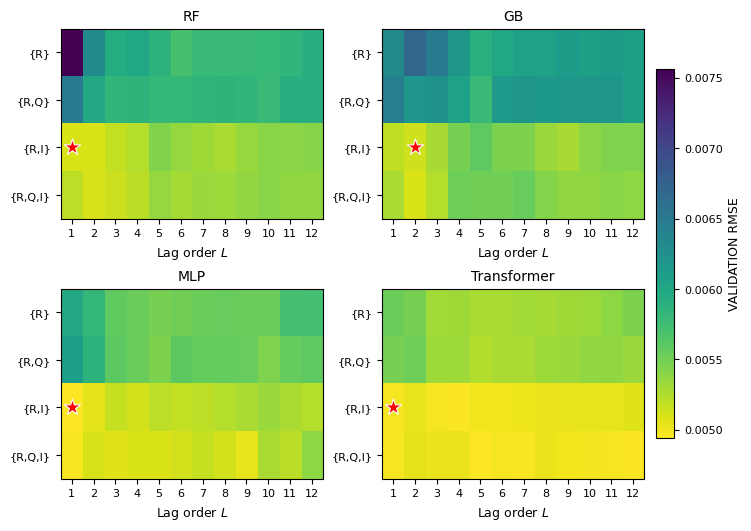

Exported: c:\Users\Rajiv Nawal\OneDrive\Documents\GITREPOS\HSBC-AN-RN\CODEWORK\Linus' Task Re-Do\plots\empirical_work\fig_flexible_structure_search_I.pdf
Exported: c:\Users\Rajiv Nawal\OneDrive\Documents\GITREPOS\HSBC-AN-RN\CODEWORK\Linus' Task Re-Do\plots\empirical_work\fig_flexible_structure_search_I.png
Exported: c:\Users\Rajiv Nawal\OneDrive\Documents\GITREPOS\HSBC-AN-RN\CODEWORK\Linus' Task Re-Do\plots\dissertation\fig_flexible_structure_search_I.pdf
Exported: c:\Users\Rajiv Nawal\OneDrive\Documents\GITREPOS\HSBC-AN-RN\CODEWORK\Linus' Task Re-Do\plots\dissertation\fig_flexible_structure_search_I.png


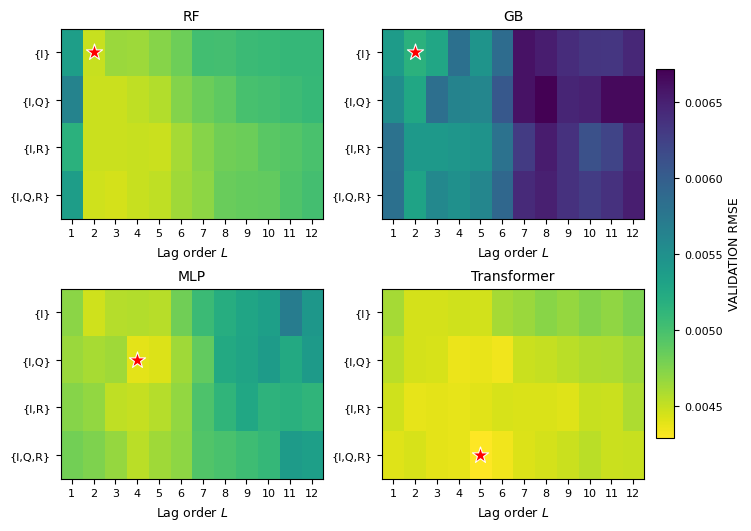

In [7]:
# ============================================================
# DISSERTATION EXPORT
# N19 flexible-model structure-search heatmaps
#
# Uses the already-computed `structure_search_validation`.
# No model fitting or structure selection is rerun.
# ============================================================

from pathlib import Path


# ------------------------------------------------------------
# 1. Output directories
# ------------------------------------------------------------

EXPORT_DIRS = [
    ROOT / "plots" / "empirical_work",
    ROOT / "plots" / "dissertation",
]

for directory in EXPORT_DIRS:
    directory.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 2. Thesis-ready export function
# ------------------------------------------------------------

def export_structure_search_heatmap(target, filename_stem):

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(7.4, 5.2),
        constrained_layout=True,
    )

    # Use one colour scale across all four model panels
    # for the same target.
    target_values = structure_search_validation.loc[
        structure_search_validation["target"].eq(target),
        "validation_RMSE",
    ]

    vmin = float(target_values.min())
    vmax = float(target_values.max())

    image = None

    model_titles = {
        "RF": "RF",
        "GB": "GB",
        "MLP": "MLP",
        "TRANSFORMER": "Transformer",
    }

    for ax, model in zip(axes.ravel(), MODEL_FAMILIES):

        subset = structure_search_validation.loc[
            structure_search_validation["target"].eq(target)
            & structure_search_validation["model"].eq(model)
        ].copy()

        parent_order = [
            "{" + ",".join(parents) + "}"
            for parents in PARENT_SETS[target]
        ]

        matrix = (
            subset
            .pivot(
                index="parent_label",
                columns="lag_order",
                values="validation_RMSE",
            )
            .reindex(
                index=parent_order,
                columns=range(1, 13),
            )
        )

        image = ax.imshow(
            matrix.to_numpy(),
            aspect="auto",
            cmap="viridis_r",
            vmin=vmin,
            vmax=vmax,
        )

        # Selected specification under the frozen
        # 1% parsimony rule.
        chosen = subset.loc[subset["selected"]].iloc[0]

        ax.scatter(
            int(chosen["lag_order"]) - 1,
            parent_order.index(chosen["parent_label"]),
            marker="*",
            s=150,
            color="red",
            edgecolor="white",
            linewidth=0.8,
            zorder=3,
        )

        ax.set_xticks(
            range(12),
            range(1, 13),
        )

        ax.set_yticks(
            range(len(parent_order)),
            parent_order,
        )

        ax.set_xlabel(
            "Lag order $L$",
            fontsize=9,
        )

        ax.set_title(
            model_titles[model],
            fontsize=10,
        )

        ax.tick_params(
            axis="both",
            labelsize=8,
        )


    # --------------------------------------------------------
    # 3. Shared colour bar
    # --------------------------------------------------------

    colorbar = fig.colorbar(
        image,
        ax=axes,
        shrink=0.82,
        pad=0.02,
    )

    colorbar.set_label(
        "VALIDATION RMSE",
        fontsize=9,
    )

    colorbar.ax.tick_params(
        labelsize=8,
    )


    # --------------------------------------------------------
    # 4. Export PDF and PNG to both thesis folders
    #
    # No internal overall title is added because the LaTeX
    # caption will describe the figure.
    # --------------------------------------------------------

    for directory in EXPORT_DIRS:

        pdf_path = directory / f"{filename_stem}.pdf"
        png_path = directory / f"{filename_stem}.png"

        fig.savefig(
            pdf_path,
            format="pdf",
            bbox_inches="tight",
        )

        fig.savefig(
            png_path,
            format="png",
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
        )

        print(f"Exported: {pdf_path}")
        print(f"Exported: {png_path}")

    plt.show()
    plt.close(fig)


# ------------------------------------------------------------
# 5. Export realised and implied structure searches
# ------------------------------------------------------------

export_structure_search_heatmap(
    target="R",
    filename_stem="fig_flexible_structure_search_R",
)

export_structure_search_heatmap(
    target="I",
    filename_stem="fig_flexible_structure_search_I",
)

The selected table above is the frozen output of the non-parametric search. RF selected {R,I} at L=1 and {I} at L=2; GB selected {R,I} at L=2 and {I} at L=2; MLP selected {R,I} at L=1 and {I,Q} at L=4; Transformer selected {R,I} at L=1 and {I,Q,R} at L=5 for R and I respectively. Parsimony changed the raw minimum-RMSE winner for RF on both targets, GB for R, and Transformer for R. Only now may the classical N16 benchmark be opened.

## 19.3 Post-freeze comparison with N16 GC and TDMI

N16 remains an external benchmark rather than an input. The probe-based Transformer structure search independently selected the same cross-variable retain/drop pattern as the N16 conditional-Granger benchmark: I → R, Q → I, and R → I were retained, while Q → R was not. It selected lag depths L_R=1 and L_I=5 rather than the parametric 1/12 orders. The subsequent final-hyperparameter stability audit finds that the Transformer-I parent set is mildly probe-sensitive (selected-to-best RMSE ratio 1.016059, outside the pre-specified 1% band), so this agreement is evidence from the frozen probe-based selection rather than a fully hyperparameter-invariant graph. For I, MLP retains Q only and RF/GB retain own history only. Agreement is corroborating predictive evidence; disagreement may reflect nonlinear relationships or model instability. Neither establishes structural economic causation.

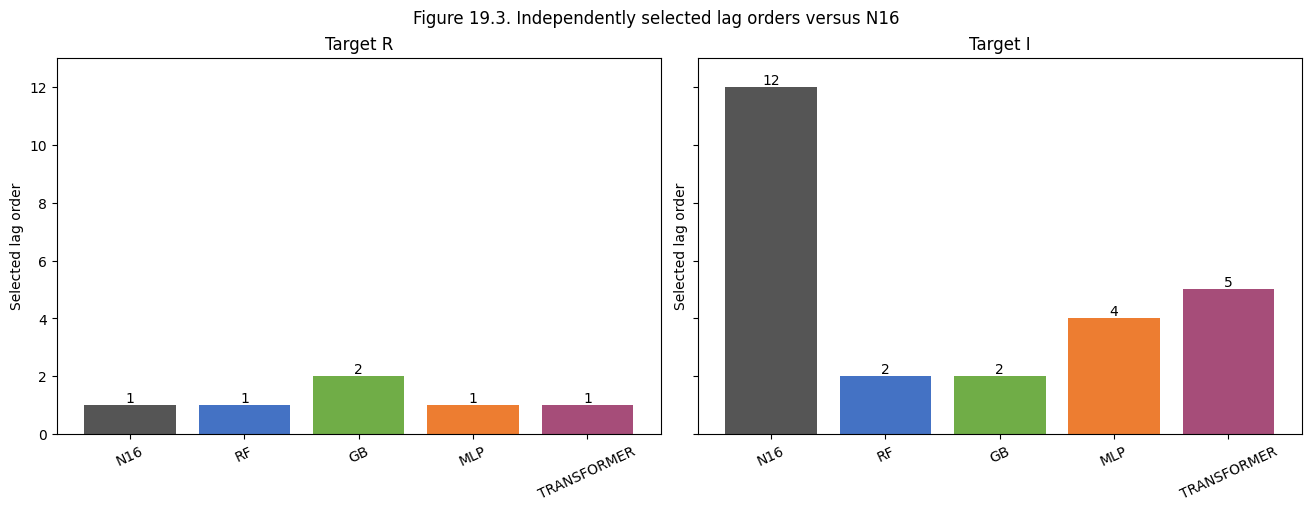

,row_type,target,candidate_source,N16_GC_retain,N16_TDMI_summary,N16_selected_lag_order,RF_retain,RF_selected_lag_order,GB_retain,GB_selected_lag_order,MLP_retain,MLP_selected_lag_order,TRANSFORMER_retain,TRANSFORMER_selected_lag_order
0,EDGE,R,Q,False,support=True; peak_lag=1; train_value=0.062370...,NaN,False,NaN,False,NaN,False,NaN,False,NaN
1,EDGE,R,I,True,support=True; peak_lag=1; train_value=0.308911...,NaN,True,NaN,True,NaN,True,NaN,True,NaN
2,EDGE,I,Q,True,support=True; peak_lag=1; train_value=0.086976...,NaN,False,NaN,False,NaN,True,NaN,True,NaN
3,EDGE,I,R,True,support=True; peak_lag=1; train_value=0.279067...,NaN,False,NaN,False,NaN,False,NaN,True,NaN
4,LAG_ORDER,R,OWN_HISTORY_ORDER,NaN,,1.0,NaN,1.0,NaN,2.0,NaN,1.0,NaN,1.0
5,LAG_ORDER,I,OWN_HISTORY_ORDER,NaN,,12.0,NaN,2.0,NaN,2.0,NaN,4.0,NaN,5.0


In [8]:
assert STRUCTURES_FROZEN

# Load the authoritative N16 primary specification.
# The exported CSV may contain blank/repeated blocks, so do not use .iloc[0]
# before identifying an actual populated specification row.
spec_16_all = pd.read_csv(PROCESSED / "16_primary_specification.csv")

valid_spec_mask = (
    pd.to_numeric(
        spec_16_all["selected_realised_order"],
        errors="coerce",
    ).notna()
    &
    pd.to_numeric(
        spec_16_all["selected_implied_order"],
        errors="coerce",
    ).notna()
)

spec_16_candidates = spec_16_all.loc[valid_spec_mask].copy()

assert len(spec_16_candidates) > 0, (
    "Could not find a populated N16 primary-specification row."
)

# Repeated exports are harmless provided they encode the same frozen contract.
spec_16_candidates = spec_16_candidates.drop_duplicates()

spec_16 = spec_16_candidates.iloc[0]

# Verify the frozen N16 lag contract.
assert int(spec_16["selected_realised_order"]) == 1
assert int(spec_16["selected_implied_order"]) == 12

# Load the N16 TDMI summary.
tdmi_16_all = pd.read_csv(PROCESSED / "16_tdmi_summary.csv")

# Remove blank separator rows from the exported CSV.
tdmi_16_all = tdmi_16_all.dropna(
    subset=["edge_id", "source", "target"]
).copy()

# Keep only the canonical weekday-normalised primary specification.
primary_mask = (
    tdmi_16_all["primary_specification"]
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(["true", "1"])
)

weekday_mask = (
    tdmi_16_all["iv_specification"]
    .astype(str)
    .str.strip()
    .eq("WEEKDAY_NORM_IV")
)

tdmi_16 = tdmi_16_all.loc[
    primary_mask & weekday_mask
].copy()

# The CSV currently contains repeated copies of the same N16 TDMI block.
# Keep one copy of each unique cross-variable edge.
tdmi_16 = (
    tdmi_16
    .drop_duplicates(
        subset=["edge_id", "source", "target"],
        keep="first",
    )
    .copy()
)

# N19 compares these four N16 cross-variable TDMI relationships.
required_tdmi_edges = {
    ("squared_return", "realised_variance_ann_252"),
    ("implied_variance_ann", "realised_variance_ann_252"),
    ("squared_return", "implied_variance_ann"),
    ("realised_variance_ann_252", "implied_variance_ann"),
}

observed_tdmi_edges = set(
    zip(tdmi_16["source"], tdmi_16["target"])
)

assert observed_tdmi_edges == required_tdmi_edges, (
    "Unexpected N16 primary TDMI edge set.\n"
    f"Expected: {required_tdmi_edges}\n"
    f"Observed: {observed_tdmi_edges}"
)

assert len(tdmi_16) == 4, (
    f"Expected 4 unique primary N16 TDMI edges, found {len(tdmi_16)}"
)


def as_bool(value):
    return str(value).strip().lower() in {"true", "1"}

edge_contract = [
    ("R", "Q", "retain_Q_to_R", "squared_return", "realised_variance_ann_252"),
    ("R", "I", "retain_I_to_R", "implied_variance_ann", "realised_variance_ann_252"),
    ("I", "Q", "retain_Q_to_I", "squared_return", "implied_variance_ann"),
    ("I", "R", "retain_R_to_I", "realised_variance_ann_252", "implied_variance_ann"),
]
comparison_rows = []
for target, source, field, tdmi_source, tdmi_target in edge_contract:
    tdmi_row = tdmi_16.loc[
        tdmi_16["source"].eq(tdmi_source) & tdmi_16["target"].eq(tdmi_target)
    ].iloc[0]
    record = {
        "row_type": "EDGE", "target": target, "candidate_source": source,
        "N16_GC_retain": as_bool(spec_16[field]),
        "N16_TDMI_summary": (
            f"support={bool(tdmi_row['training_tdmi_support'])}; "
            f"peak_lag={int(tdmi_row['training_tdmi_peak_lag'])}; "
            f"train_value={tdmi_row['training_tdmi_value']:.6g}; "
            f"validation_p={tdmi_row['tdmi_validation_p']:.6g}"
        ),
        "N16_selected_lag_order": np.nan,
    }
    for model in MODEL_FAMILIES:
        parents = discovered_structures.loc[
            discovered_structures["model"].eq(model) & discovered_structures["target"].eq(target),
            "selected_parent_blocks",
        ].iloc[0].split("|")
        record[f"{model}_retain"] = source in parents
        record[f"{model}_selected_lag_order"] = np.nan
    comparison_rows.append(record)

for target, n16_order in [("R", int(spec_16["selected_realised_order"])), ("I", int(spec_16["selected_implied_order"]))]:
    record = {
        "row_type": "LAG_ORDER", "target": target, "candidate_source": "OWN_HISTORY_ORDER",
        "N16_GC_retain": np.nan, "N16_TDMI_summary": "",
        "N16_selected_lag_order": n16_order,
    }
    for model in MODEL_FAMILIES:
        record[f"{model}_retain"] = np.nan
        record[f"{model}_selected_lag_order"] = int(discovered_structures.loc[
            discovered_structures["model"].eq(model) & discovered_structures["target"].eq(target),
            "selected_lag_order",
        ].iloc[0])
    comparison_rows.append(record)
structure_vs_n16 = pd.DataFrame(comparison_rows)
selection_audit["n16_structure_used_for_selection"] = False
assert selection_audit["n16_structure_used_for_selection"] is False

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True, constrained_layout=True)
for ax, target in zip(axes, TARGETS):
    row = structure_vs_n16.loc[
        structure_vs_n16["row_type"].eq("LAG_ORDER") & structure_vs_n16["target"].eq(target)
    ].iloc[0]
    labels = ["N16", *MODEL_FAMILIES]
    values = [row["N16_selected_lag_order"], *[row[f"{model}_selected_lag_order"] for model in MODEL_FAMILIES]]
    bars = ax.bar(labels, values, color=["#555555", "#4472C4", "#70AD47", "#ED7D31", "#A64D79"])
    ax.bar_label(bars, fmt="%.0f")
    ax.set_ylim(0, 13)
    ax.set_title(f"Target {target}")
    ax.set_ylabel("Selected lag order")
    ax.tick_params(axis="x", rotation=25)
fig.suptitle("Figure 19.3. Independently selected lag orders versus N16")
save_figure(fig, "19_figure_19_3_selected_lag_orders.png")
display(structure_vs_n16)

## 19.3a Matched flexible-model predictive relevance

N16 compares restricted and unrestricted linear models to ask whether a source history adds conditional predictive information. The following diagnostic asks the analogous forecasting question in the frozen flexible-model search. It is derived from the existing TRAIN-fitted and VALIDATION-scored candidate grid; it neither refits models nor reselects any structure.

For model family M, target Y, and cross-variable source X, otherwise matched candidate specifications differ only by source X:

$$
\Delta RMSE_{M,X\rightarrow Y}
=
RMSE_{M,Y,-X}
-
RMSE_{M,Y,+X}.
$$

$$
\Delta RMSE^{\%}_{M,X\rightarrow Y}
=
100\frac{RMSE_{M,Y,-X}-RMSE_{M,Y,+X}}{RMSE_{M,Y,-X}}.
$$

A positive value means that inclusion of X lowers VALIDATION RMSE within that model, selected-lag, and local parent-set context. A value that is zero within the numerical tolerance means no numerically detectable difference; a negative value means that exclusion of X improves this matched comparison. This is a flexible-model, Granger-style predictive-relevance diagnostic. It is not a Granger F statistic, has no conventional GC p-value, and does not identify structural economic causality.

The main matrix covers cross-variable questions only: Q and I for target R, and Q and R for target I. Own histories remain persistence baselines rather than cross-variable arrows.

The matched source-removal diagnostic is explanatory. The canonical flexible structures continue to be determined by the original TRAIN-fit / VALIDATION-RMSE candidate search and frozen 1% parsimony rule. No structure is reselected from the matched delta-RMSE table.

### Matched parent-set comparison

This compares separately fitted candidate specifications with and without a source history and asks whether including that source improves out-of-sample VALIDATION forecasting.

### Permutation importance

This perturbs a source block within an already fitted model and asks how much that fitted model depends on the input block. It is a post-fit dependence diagnostic, distinct from the matched forecast comparison. Neither diagnostic is structural causal identification.

N16 versus N19 matched predictive-relevance comparison


,source,target,N16_decision,RF_delta_rmse,RF_relative_delta_rmse_pct,GB_delta_rmse,GB_relative_delta_rmse_pct,MLP_delta_rmse,MLP_relative_delta_rmse_pct,TRANSFORMER_delta_rmse,TRANSFORMER_relative_delta_rmse_pct
0,Q,R,DROP,-0.000108,-2.119343,0.000048,0.943710,-0.000022,-0.440365,0.000005,0.092266
1,I,R,RETAIN,0.002473,32.703394,0.001563,23.339961,0.001034,17.303481,0.000549,9.934640
2,Q,I,RETAIN,0.000004,0.084139,-0.000103,-1.988440,0.000180,3.946165,0.000114,2.577679
3,R,I,RETAIN,0.000006,0.138772,-0.000236,-4.570050,-0.000150,-3.413255,0.000080,1.827077


C:\Users\Rajiv Nawal\AppData\Local\Temp\ipykernel_31244\3146369068.py:161: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(left=0.08,right=0.88,top=0.90,bottom=0.17,wspace=0.28,hspace=0.35)


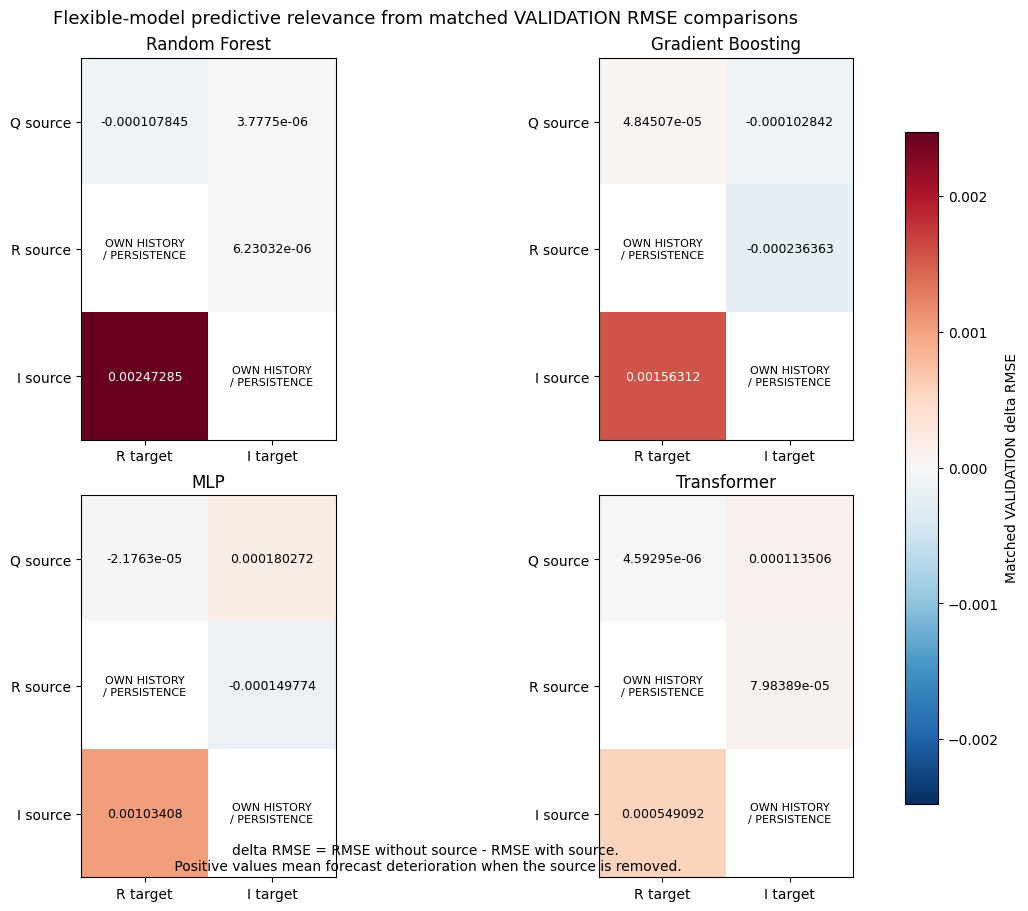

,model,model_family,target,source,selected_parent_set,selected_lag,parents_without_source,parents_with_source,rmse_without_source,rmse_with_source,delta_rmse,relative_delta_rmse_pct,source_selected_in_primary,predictive_direction,interpretation,N16_GC_retain,validation_only,diagnostic_role
0,GB,Gradient Boosting,I,Q,I,2,I,I|Q,0.005172,0.005275,-0.000103,-1.988440,False,NEGATIVE,Including the source raises matched VALIDATION...,True,True,matched flexible-model predictive relevance; n...
1,GB,Gradient Boosting,I,R,I,2,I,I|R,0.005172,0.005408,-0.000236,-4.570050,False,NEGATIVE,Including the source raises matched VALIDATION...,True,True,matched flexible-model predictive relevance; n...
9,GB,Gradient Boosting,R,I,R|I,2,R,R|I,0.006697,0.005134,0.001563,23.339961,True,POSITIVE,Including the source lowers matched VALIDATION...,True,True,matched flexible-model predictive relevance; n...
8,GB,Gradient Boosting,R,Q,R|I,2,R|I,R|Q|I,0.005134,0.005086,0.000048,0.943710,False,POSITIVE,Including the source lowers matched VALIDATION...,False,True,matched flexible-model predictive relevance; n...
2,MLP,MLP,I,Q,I|Q,4,I,I|Q,0.004568,0.004388,0.000180,3.946165,True,POSITIVE,Including the source lowers matched VALIDATION...,True,True,matched flexible-model predictive relevance; n...
3,MLP,MLP,I,R,I|Q,4,I|Q,I|Q|R,0.004388,0.004538,-0.000150,-3.413255,False,NEGATIVE,Including the source raises matched VALIDATION...,True,True,matched flexible-model predictive relevance; n...
11,MLP,MLP,R,I,R|I,1,R,R|I,0.005976,0.004942,0.001034,17.303481,True,POSITIVE,Including the source lowers matched VALIDATION...,True,True,matched flexible-model predictive relevance; n...
10,MLP,MLP,R,Q,R|I,1,R|I,R|Q|I,0.004942,0.004964,-0.000022,-0.440365,False,NEGATIVE,Including the source raises matched VALIDATION...,False,True,matched flexible-model predictive relevance; n...
4,RF,Random Forest,I,Q,I,2,I,I|Q,0.004490,0.004486,0.000004,0.084139,False,POSITIVE,Including the source lowers matched VALIDATION...,True,True,matched flexible-model predictive relevance; n...
5,RF,Random Forest,I,R,I,2,I,I|R,0.004490,0.004483,0.000006,0.138772,False,POSITIVE,Including the source lowers matched VALIDATION...,True,True,matched flexible-model predictive relevance; n...


In [9]:
MODEL_FAMILY_NAMES = {
    "RF": "Random Forest",
    "GB": "Gradient Boosting",
    "MLP": "MLP",
    "TRANSFORMER": "Transformer",
}
CROSS_VARIABLE_SOURCES = {
    "R": ("Q", "I"),
    "I": ("Q", "R"),
}
N16_RETAIN_FIELDS = {
    ("R", "Q"): "retain_Q_to_R",
    ("R", "I"): "retain_I_to_R",
    ("I", "Q"): "retain_Q_to_I",
    ("I", "R"): "retain_R_to_I",
}

def candidate_parent_set(target, included_states):
    included_states = set(included_states)
    matches = [
        parents for parents in PARENT_SETS[target]
        if set(parents) == included_states
    ]
    assert len(matches) == 1, (target, included_states, matches)
    return tuple(matches[0])

def candidate_validation_rmse(model, target, parents, lag_order):
    parent_blocks = "|".join(parents)
    matching_candidate = structure_search_validation.loc[
        structure_search_validation["model"].eq(model)
        & structure_search_validation["target"].eq(target)
        & structure_search_validation["parent_blocks"].eq(parent_blocks)
        & structure_search_validation["lag_order"].eq(lag_order)
    ]
    assert len(matching_candidate) == 1
    return float(matching_candidate.iloc[0]["validation_RMSE"])

matched_relevance_rows = []
for selected_row in discovered_structures.itertuples(index=False):
    model = selected_row.model
    target = selected_row.target
    selected_parents = tuple(selected_row.selected_parent_blocks.split("|"))
    selected_lag = int(selected_row.selected_lag_order)
    for source in CROSS_VARIABLE_SOURCES[target]:
        context_parents = tuple(
            parent for parent in selected_parents if parent != source
        )
        parents_without_source = candidate_parent_set(target, context_parents)
        parents_with_source = candidate_parent_set(
            target, [*context_parents, source]
        )
        rmse_without_source = candidate_validation_rmse(
            model, target, parents_without_source, selected_lag
        )
        rmse_with_source = candidate_validation_rmse(
            model, target, parents_with_source, selected_lag
        )
        delta_rmse = rmse_without_source - rmse_with_source
        relative_delta_rmse_pct = 100 * delta_rmse / rmse_without_source
        if np.isclose(delta_rmse, 0.0, rtol=0.0, atol=1e-12):
            predictive_direction = "ZERO_WITHIN_NUMERICAL_TOLERANCE"
            interpretation = "Matched source inclusion is zero within the 1e-12 numerical tolerance."
        elif delta_rmse > 0:
            predictive_direction = "POSITIVE"
            interpretation = "Including the source lowers matched VALIDATION RMSE."
        else:
            predictive_direction = "NEGATIVE"
            interpretation = "Including the source raises matched VALIDATION RMSE."
        matched_relevance_rows.append({
            "model": model,
            "model_family": MODEL_FAMILY_NAMES[model],
            "target": target,
            "source": source,
            "selected_parent_set": "|".join(selected_parents),
            "selected_lag": selected_lag,
            "parents_without_source": "|".join(parents_without_source),
            "parents_with_source": "|".join(parents_with_source),
            "rmse_without_source": rmse_without_source,
            "rmse_with_source": rmse_with_source,
            "delta_rmse": delta_rmse,
            "relative_delta_rmse_pct": relative_delta_rmse_pct,
            "source_selected_in_primary": bool(source in selected_parents),
            "predictive_direction": predictive_direction,
            "interpretation": interpretation,
            "N16_GC_retain": as_bool(spec_16[N16_RETAIN_FIELDS[(target, source)]]),
            "validation_only": True,
            "diagnostic_role": "matched flexible-model predictive relevance; not structure selection",
        })

matched_flexible_predictive_relevance = pd.DataFrame(matched_relevance_rows)
reverse_engineering_uses_test = False
assert reverse_engineering_uses_test is False

# Each cross-variable comparison preserves its model, target, selected lag, and own-history baseline.
for comparison in matched_flexible_predictive_relevance.itertuples(index=False):
    without_source = tuple(comparison.parents_without_source.split("|"))
    with_source = tuple(comparison.parents_with_source.split("|"))
    assert comparison.model in MODEL_FAMILIES
    assert comparison.target in TARGETS
    assert comparison.selected_lag >= 1
    assert comparison.target in without_source and comparison.target in with_source
    assert set(with_source) == set(without_source) | {comparison.source}
    assert comparison.source not in without_source

# This compact table compares the frozen N16 linear-GC decision with the matched N19 values.
edge_order = [("Q", "R"), ("I", "R"), ("Q", "I"), ("R", "I")]
n16_n19_predictive_structure_comparison = pd.DataFrame(edge_order, columns=["source", "target"])
n16_n19_predictive_structure_comparison["N16_decision"] = [
    "RETAIN" if as_bool(spec_16[N16_RETAIN_FIELDS[(target, source)]]) else "DROP"
    for source, target in edge_order
]
for model in MODEL_FAMILIES:
    model_rows = matched_flexible_predictive_relevance.loc[
        matched_flexible_predictive_relevance["model"].eq(model),
        ["source", "target", "delta_rmse", "relative_delta_rmse_pct"],
    ]
    n16_n19_predictive_structure_comparison = n16_n19_predictive_structure_comparison.merge(
        model_rows.rename(columns={
            "delta_rmse": f"{model}_delta_rmse",
            "relative_delta_rmse_pct": f"{model}_relative_delta_rmse_pct",
        }),
        on=["source", "target"], how="left", validate="one_to_one",
    )
assert len(n16_n19_predictive_structure_comparison) == 4
assert n16_n19_predictive_structure_comparison.filter(like="_delta_rmse").notna().all().all()
print("N16 versus N19 matched predictive-relevance comparison")
display(n16_n19_predictive_structure_comparison)

# The heatmaps use the continuous matched VALIDATION delta-RMSE values, not selection labels.
source_order = ["Q", "R", "I"]
target_order = ["R", "I"]
all_delta_rmse = matched_flexible_predictive_relevance["delta_rmse"].to_numpy(dtype=float)
colour_limit = max(float(np.nanmax(np.abs(all_delta_rmse))), 1e-12)
fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
image = None
for ax, model in zip(axes.flat, MODEL_FAMILIES):
    model_values = matched_flexible_predictive_relevance.loc[
        matched_flexible_predictive_relevance["model"].eq(model),
        ["source", "target", "delta_rmse"],
    ].set_index(["source", "target"])["delta_rmse"]
    value_grid = np.full((len(source_order), len(target_order)), np.nan)
    for row_index, source in enumerate(source_order):
        for column_index, target in enumerate(target_order):
            if source != target:
                value_grid[row_index, column_index] = model_values.loc[(source, target)]
    image = ax.imshow(value_grid, cmap="RdBu_r", vmin=-colour_limit, vmax=colour_limit)
    for row_index, source in enumerate(source_order):
        for column_index, target in enumerate(target_order):
            if source == target:
                ax.text(column_index, row_index, "OWN HISTORY\n/ PERSISTENCE", ha="center", va="center", fontsize=8)
            else:
                value = value_grid[row_index, column_index]
                text_colour = "white" if abs(value) > colour_limit * 0.55 else "black"
                ax.text(column_index, row_index, f"{value:.6g}", ha="center", va="center", color=text_colour, fontsize=9)
    ax.set_xticks(range(len(target_order)), [f"{target} target" for target in target_order])
    ax.set_yticks(range(len(source_order)), [f"{source} source" for source in source_order])
    ax.set_title(MODEL_FAMILY_NAMES[model])
colour_bar = fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.82)
colour_bar.set_label("Matched VALIDATION delta RMSE")
fig.suptitle("Flexible-model predictive relevance from matched VALIDATION RMSE comparisons", fontsize=13)
fig.subplots_adjust(left=0.08,right=0.88,top=0.90,bottom=0.17,wspace=0.28,hspace=0.35)
fig.text(0.5, 0.035, "delta RMSE = RMSE without source - RMSE with source.\n Positive values mean forecast deterioration when the source is removed.", ha="center",va="bottom", fontsize=10)
save_figure(fig, "19_figure_matched_predictive_relevance.png")
selected_structure_reference = {
    ("RF", "R"): ("R|I", 1),
    ("GB", "R"): ("R|I", 2),
    ("MLP", "R"): ("R|I", 1),
    ("TRANSFORMER", "R"): ("R|I", 1),
    ("RF", "I"): ("I", 2),
    ("GB", "I"): ("I", 2),
    ("MLP", "I"): ("I|Q", 4),
    ("TRANSFORMER", "I"): ("I|Q|R", 5),
}
selected_structure_actual = {
    (row.model, row.target): (
        row.selected_parent_blocks,
        int(row.selected_lag_order),
    )
    for row in discovered_structures.itertuples(index=False)
}
assert selected_structure_actual == selected_structure_reference
assert len(matched_flexible_predictive_relevance) == 16
assert matched_flexible_predictive_relevance["validation_only"].all()
assert reverse_engineering_uses_test is False
assert set(matched_flexible_predictive_relevance[["target", "source"]].itertuples(index=False, name=None)) == {
    ("R", "Q"), ("R", "I"), ("I", "Q"), ("I", "R"),
}
assert matched_flexible_predictive_relevance["selected_lag"].between(1, L_MAX).all()
display(matched_flexible_predictive_relevance.sort_values(["model", "target", "source"]))


## 19.3b Reading the matched N16–N19 comparison

The table and four-panel figure report the executed continuous matched VALIDATION delta-RMSE values for each flexible model family, alongside the frozen N16 decision. Positive values support incremental predictive relevance in that matched local context; negative values favour the otherwise matched model without the source. Agreement across flexible model families is stronger predictive evidence, while disagreement documents model-dependent nonlinear predictive structure. These comparisons are evidence for forecasting-based, Granger-style predictive dependence, not structural causal identification and not a new voting or retention rule.

## 19.4 Hyperparameter selection after structure freeze

Each discovered parent set and lag order now remains fixed. The original small candidate grid is evaluated with TRAIN fitting and ordinary VALIDATION scoring. Neural candidates retain the three-seed discipline; their final refit duration is the median best epoch across the selected candidate's development seeds. A subsequent diagnostic rechecks all four parent sets at the selected lag under final hyperparameters without changing the frozen structure.

In [10]:
def selected_structure(model, target):
    row = discovered_structures.loc[
        discovered_structures["model"].eq(model) & discovered_structures["target"].eq(target)
    ].iloc[0]
    return tuple(row["selected_parent_blocks"].split("|")), int(row["selected_lag_order"])

hyperparameter_rows = []
selected_hyperparameters = {}
frozen_epochs = {}
for model in (() if REUSE_FROZEN_SELECTION else MODEL_FAMILIES):
    for target in TARGETS:
        parents, lag_order = selected_structure(model, target)
        columns = feature_columns(parents, lag_order)
        train_frame = model_frame(target, "train", parents, lag_order)
        validation_frame = model_frame(target, "validation", parents, lag_order)
        candidate_results = []
        for config_id in GRIDS[model]:
            if model in {"RF", "GB"}:
                estimator = make_tree(model, config_id)
                estimator.fit(train_frame[columns], train_frame[target])
                prediction = estimator.predict(validation_frame[columns])
                metric = compute_metrics(validation_frame[target], prediction)
                mean_rmse, mean_mae, median_epoch = metric["RMSE"], metric["MAE"], np.nan
                seed_count = 1
            else:
                seed_metrics, seed_epochs = [], []
                for seed in SEEDS:
                    network, scale, best_epoch = train_neural_early(
                        model, config_id, seed, train_frame, validation_frame,
                        target, parents, lag_order,
                    )
                    prediction = predict_neural(network, validation_frame, columns, scale, model, lag_order, len(parents))
                    metric_seed = compute_metrics(validation_frame[target], prediction)
                    neural_seed_records.append({
                        "stage": "HYPERPARAMETER_SELECTION", "model": model, "target": target,
                        "candidate_id": config_id, "config_id": config_id, "seed": seed,
                        "parent_blocks": "|".join(parents), "lag_order": lag_order,
                        "best_epoch": best_epoch, "validation_RMSE": metric_seed["RMSE"],
                        "validation_MAE": metric_seed["MAE"],
                    })
                    seed_metrics.append(metric_seed)
                    seed_epochs.append(best_epoch)
                    del network
                mean_rmse = float(np.mean([row["RMSE"] for row in seed_metrics]))
                mean_mae = float(np.mean([row["MAE"] for row in seed_metrics]))
                median_epoch = int(np.median(seed_epochs))
                seed_count = len(SEEDS)
            result = {
                "model": model, "target": target, "candidate_id": config_id,
                "hyperparameters": str(GRIDS[model][config_id]),
                "parent_blocks": "|".join(parents), "lag_order": lag_order,
                "mean_validation_RMSE": mean_rmse, "mean_validation_MAE": mean_mae,
                "seed_count": seed_count, "median_best_epoch": median_epoch,
                "selected": False,
            }
            hyperparameter_rows.append(result)
            candidate_results.append(result)
        winner = sorted(candidate_results, key=lambda row: (row["mean_validation_RMSE"], row["candidate_id"]))[0]
        winner["selected"] = True
        selected_hyperparameters[(model, target)] = winner["candidate_id"]
        if model in {"MLP", "TRANSFORMER"}:
            frozen_epochs[(model, target)] = int(winner["median_best_epoch"])
        print(f"Hyperparameter selection complete: {model} target {target}")

hyperparameter_selection_validation = pd.read_csv(PROCESSED / "19_hyperparameter_selection_validation.csv") if REUSE_FROZEN_SELECTION else pd.DataFrame(hyperparameter_rows)
selected_spec_rows = []
for model in (() if REUSE_FROZEN_SELECTION else MODEL_FAMILIES):
    for target in TARGETS:
        parents, lag_order = selected_structure(model, target)
        config_id = selected_hyperparameters[(model, target)]
        structure_row = discovered_structures.loc[
            discovered_structures["model"].eq(model) & discovered_structures["target"].eq(target)
        ].iloc[0]
        selected_spec_rows.append({
            "model": model, "target": target,
            "selected_parent_blocks": "|".join(parents),
            "selected_lag_order": lag_order,
            "structure_candidate_id": structure_row["selected_candidate_id"],
            "hyperparameter_candidate_id": config_id,
            "selected_hyperparameters": str(GRIDS[model][config_id]),
            "final_fixed_epochs": frozen_epochs.get((model, target), np.nan),
            "neural_final_ensemble_seeds": "19|119|219" if model in {"MLP", "TRANSFORMER"} else "",
        })
selected_model_specifications = (pd.read_csv(PROCESSED / "19_selected_model_specifications.csv") if REUSE_FROZEN_SELECTION else pd.DataFrame(selected_spec_rows)).sort_values(["target", "model"]).reset_index(drop=True)
if REUSE_FROZEN_SELECTION:
    selected_hyperparameters = dict(FROZEN_SELECTED_CONFIGURATIONS)
    frozen_epochs = dict(FROZEN_FIXED_EPOCHS)
    for (model, target), config_id in FROZEN_SELECTED_CONFIGURATIONS.items():
        row = selected_model_specifications["model"].eq(model) & selected_model_specifications["target"].eq(target)
        assert row.sum() == 1
        selected_model_specifications.loc[row, "hyperparameter_candidate_id"] = config_id
        selected_model_specifications.loc[row, "selected_hyperparameters"] = str(GRIDS[model][config_id])
        if (model, target) in FROZEN_FIXED_EPOCHS: selected_model_specifications.loc[row, "final_fixed_epochs"] = FROZEN_FIXED_EPOCHS[(model, target)]
if REUSE_FROZEN_SELECTION:
    assert selected_hyperparameters == FROZEN_SELECTED_CONFIGURATIONS
    assert frozen_epochs == FROZEN_FIXED_EPOCHS
SPECIFICATIONS_FROZEN = True
display(selected_model_specifications)

,model,target,selected_parent_blocks,selected_lag_order,structure_candidate_id,hyperparameter_candidate_id,selected_hyperparameters,final_fixed_epochs,neural_final_ensemble_seeds
0,GB,I,I,2,I__I__L02,GB_02,"{'n_estimators': 200, 'learning_rate': 0.05}",NaN,NaN
1,MLP,I,I|Q,4,I__I+Q__L04,MLP_03,"([32, 16], 0.001)",77.0,19|119|219
2,RF,I,I,2,I__I__L02,RF_01,"{'max_depth': 8, 'min_samples_leaf': 5}",NaN,NaN
3,TRANSFORMER,I,I|Q|R,5,I__I+Q+R__L05,TR_03,"((24, 4, 48), 0.001)",19.0,19|119|219
4,GB,R,R|I,2,R__R+I__L02,GB_02,"{'n_estimators': 200, 'learning_rate': 0.05}",NaN,NaN
5,MLP,R,R|I,1,R__R+I__L01,MLP_04,"([32, 16], 0.0003)",143.0,19|119|219
6,RF,R,R|I,1,R__R+I__L01,RF_01,"{'max_depth': 8, 'min_samples_leaf': 5}",NaN,NaN
7,TRANSFORMER,R,R|I,1,R__R+I__L01,TR_01,"((16, 2, 32), 0.001)",52.0,19|119|219


In [11]:
validation_fitted = {}
validation_neural_ensembles = {}
validation_fit_frames = {}
for model in (() if REUSE_FROZEN_SELECTION else MODEL_FAMILIES):
    for target in TARGETS:
        parents, lag_order = selected_structure(model, target)
        columns = feature_columns(parents, lag_order)
        train_frame = model_frame(target, "train", parents, lag_order)
        validation_frame = model_frame(target, "validation", parents, lag_order)
        validation_fit_frames[(model, target)] = validation_frame
        config_id = selected_hyperparameters[(model, target)]
        if model in {"RF", "GB"}:
            estimator = make_tree(model, config_id)
            estimator.fit(train_frame[columns], train_frame[target])
            validation_fitted[(model, target)] = estimator
        else:
            networks, scales = [], []
            for seed in SEEDS:
                network, scale, _ = train_neural_early(
                    model, config_id, seed, train_frame, validation_frame,
                    target, parents, lag_order,
                )
                networks.append(network)
                scales.append(scale)
            validation_neural_ensembles[(model, target)] = (networks, scales)

def validation_prediction(model, target, frame_or_array):
    global TREE_FEATURE_NAME_AUDIT_COUNT
    parents, lag_order = selected_structure(model, target)
    columns = feature_columns(parents, lag_order)
    if model in {"RF", "GB"}:
        values = frame_or_array.loc[:, columns] if isinstance(frame_or_array, pd.DataFrame) else pd.DataFrame(frame_or_array, columns=columns)
        fitted = validation_fitted[(model, target)]
        assert list(values.columns) == list(fitted.feature_names_in_)
        TREE_FEATURE_NAME_AUDIT_COUNT += 1
        return fitted.predict(values)
    networks, scales = validation_neural_ensembles[(model, target)]
    return ensemble_prediction(networks, frame_or_array, columns, scales, model, lag_order, len(parents))

stability_rows = []
for model in (() if REUSE_FROZEN_SELECTION else MODEL_FAMILIES):
    for target in TARGETS:
        selected_parents, lag_order = selected_structure(model, target)
        config_id = selected_hyperparameters[(model, target)]
        train_frame = SEARCH_SUPPORT[(target, "train")]
        validation_frame = SEARCH_SUPPORT[(target, "validation")]
        parent_results = []
        for parents in PARENT_SETS[target]:
            columns = feature_columns(parents, lag_order)
            if model in {"RF", "GB"}:
                estimator = make_tree(model, config_id)
                estimator.fit(train_frame[columns], train_frame[target])
                prediction = estimator.predict(validation_frame[columns])
                rmse = compute_metrics(validation_frame[target], prediction)["RMSE"]
            else:
                seed_rmses = []
                for seed in SEEDS:
                    network, scale, best_epoch = train_neural_early(
                        model, config_id, seed, train_frame, validation_frame,
                        target, parents, lag_order,
                    )
                    prediction = predict_neural(network, validation_frame, columns, scale, model, lag_order, len(parents))
                    rmse_seed = compute_metrics(validation_frame[target], prediction)["RMSE"]
                    neural_seed_records.append({
                        "stage": "STRUCTURE_STABILITY", "model": model, "target": target,
                        "candidate_id": "|".join(parents), "config_id": config_id, "seed": seed,
                        "parent_blocks": "|".join(parents), "lag_order": lag_order,
                        "best_epoch": best_epoch, "validation_RMSE": rmse_seed,
                        "validation_MAE": np.nan,
                    })
                    seed_rmses.append(rmse_seed)
                    del network
                rmse = float(np.mean(seed_rmses))
            parent_results.append(("|".join(parents), rmse))
        best_parent_blocks, best_rmse = min(parent_results, key=lambda item: item[1])
        selected_rmse = dict(parent_results)["|".join(selected_parents)]
        stability_rows.append({
            "model": model, "target": target,
            "selected_parent_blocks": "|".join(selected_parents),
            "selected_lag_order": lag_order,
            "final_hyperparameter_candidate_id": config_id,
            "best_parent_blocks_at_selected_lag": best_parent_blocks,
            "best_parent_RMSE_at_selected_lag": best_rmse,
            "selected_parent_RMSE_at_selected_lag": selected_rmse,
            "selected_to_best_ratio": selected_rmse / best_rmse,
            "stable_with_final_hyperparameters": bool(selected_rmse <= PARSIMONY_BAND * best_rmse),
        })
structure_stability_check = pd.read_csv(PROCESSED / "19_structure_stability_check.csv") if REUSE_FROZEN_SELECTION else pd.DataFrame(stability_rows)
assert len(structure_stability_check) == 8
display(structure_stability_check)

,model,target,selected_parent_blocks,selected_lag_order,final_hyperparameter_candidate_id,best_parent_blocks_at_selected_lag,best_parent_RMSE_at_selected_lag,selected_parent_RMSE_at_selected_lag,selected_to_best_ratio,stable_with_final_hyperparameters
0,RF,R,R|I,1,RF_02,R|I,0.005039,0.005039,1.000000,True
1,RF,I,I,2,RF_01,I|Q|R,0.004468,0.004490,1.004850,True
2,GB,R,R|I,2,GB_02,R|Q|I,0.005016,0.005168,1.030288,False
3,GB,I,I,2,GB_04,I,0.004755,0.004755,1.000000,True
4,MLP,R,R|I,1,MLP_03,R|I,0.004913,0.004913,1.000000,True
5,MLP,I,I|Q,4,MLP_01,I|Q,0.004388,0.004388,1.000000,True
6,TRANSFORMER,R,R|I,1,TR_02,R|Q|I,0.004970,0.004972,1.000421,True
7,TRANSFORMER,I,I|Q|R,5,TR_04,I|Q,0.004303,0.004372,1.016059,False


The selected specification table is reused without reopening pre-TEST selection. Final configurations are RF_01/GB_02/MLP_04/TR_01 for R and RF_01/GB_02/MLP_03/TR_03 for I. Fixed neural epochs are 143 and 52 for R MLP and Transformer, and 77 and 19 for I. The historical structure-search and stability artefacts remain provenance only; no validation result is used to replace a frozen configuration.

## 19.5 Step 2 — event-unaware forecasting

Structures, hyperparameters, and neural epoch rules are frozen. Development forecasts retain TRAIN → VALIDATION results. Final TEST forecasts refit on TRAIN+VALIDATION once, use observed lag histories for one-step-ahead prediction, and never recurse or clip. N17 is loaded as the frozen parametric benchmark and is not refit.

Model-support metrics use each discovered specification's valid dates. The primary cross-model comparison uses dates common to N17 and all four flexible models.

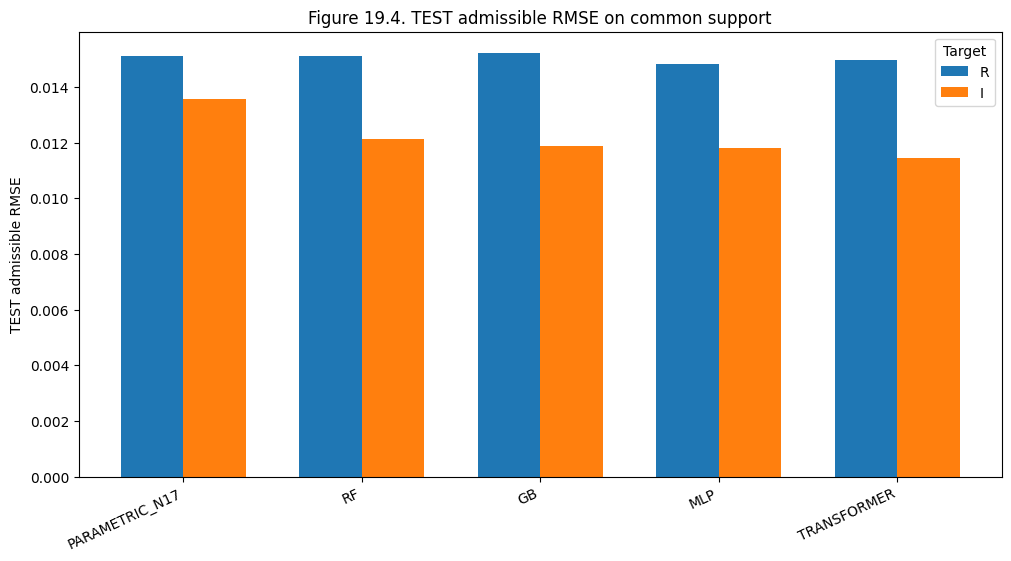

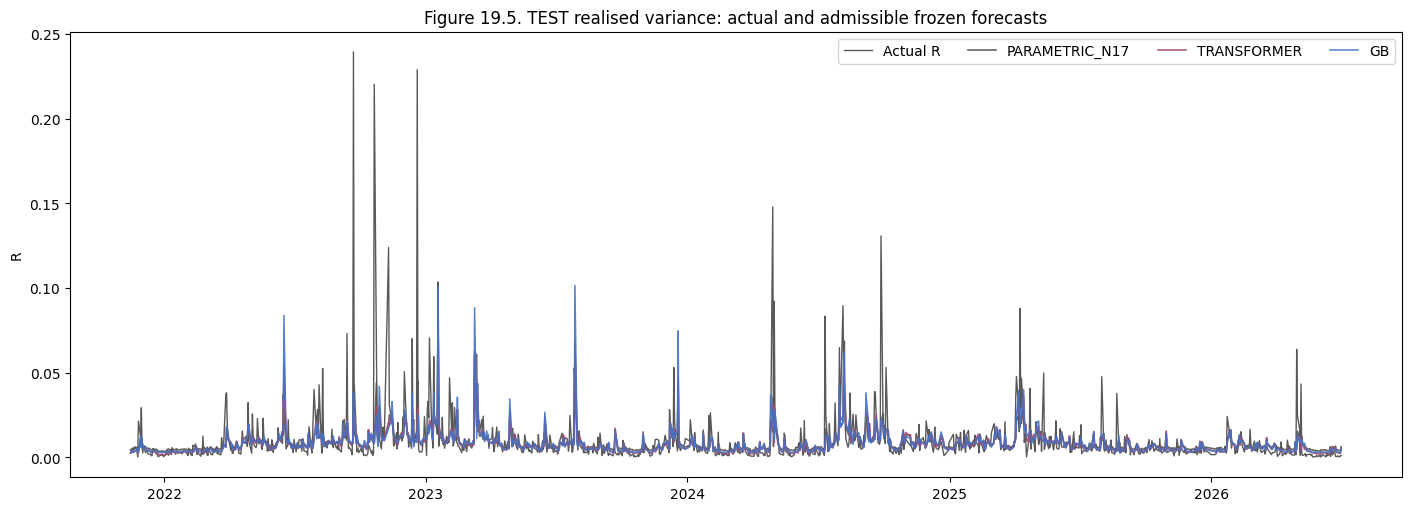

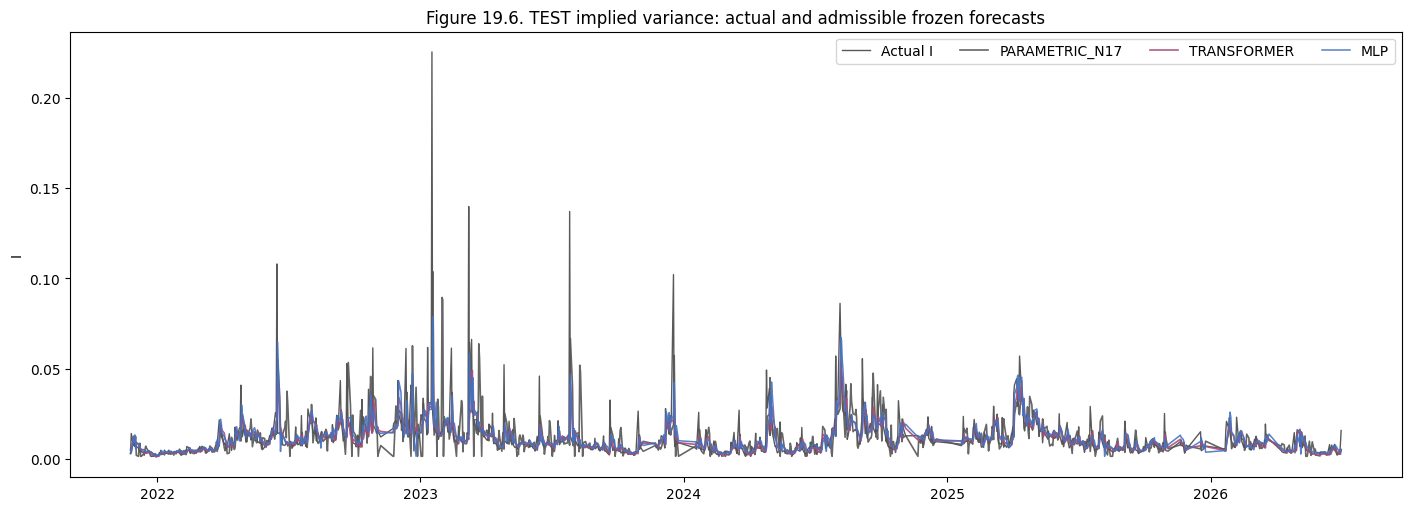

Common-support TEST metrics (canonical fields are admissible; raw fields remain diagnostics)


,support,target,model,valid_forecast_n,RMSE,MAE,QLIKE,QLIKE_valid_n,OOS_R2,nonpositive_forecast_n,raw_valid_forecast_n,raw_RMSE,raw_MAE,raw_QLIKE,raw_QLIKE_valid_n,raw_OOS_R2,raw_nonpositive_forecast_n,admissible_valid_forecast_n,admissible_RMSE,admissible_MAE,admissible_QLIKE,admissible_QLIKE_valid_n,admissible_OOS_R2,admissible_nonpositive_forecast_n,floor_activated_n
0,COMMON_ALL_MODELS,I,GB,1071,0.011889,0.004853,0.138120,1071,0.378009,0,1071,0.011889,0.004853,0.138120,1071,0.378009,0,1071,0.011889,0.004853,0.138120,1071,0.378009,0,0
1,COMMON_ALL_MODELS,I,MLP,1071,0.011799,0.004856,0.152253,1071,0.387363,0,1071,0.011826,0.004871,0.155322,1070,0.384565,1,1071,0.011799,0.004856,0.152253,1071,0.387363,0,2
2,COMMON_ALL_MODELS,I,PARAMETRIC_N17,1071,0.013572,0.006267,0.378540,1071,0.189510,0,1071,0.013857,0.006476,0.622338,1046,0.155036,25,1071,0.013572,0.006267,0.378540,1071,0.189510,0,42
3,COMMON_ALL_MODELS,I,RF,1071,0.012116,0.004877,0.133424,1071,0.354016,0,1071,0.012116,0.004877,0.133424,1071,0.354016,0,1071,0.012116,0.004877,0.133424,1071,0.354016,0,0
4,COMMON_ALL_MODELS,I,TRANSFORMER,1071,0.011452,0.004425,0.144424,1071,0.422906,0,1071,0.011452,0.004426,0.144487,1071,0.422905,0,1071,0.011452,0.004425,0.144424,1071,0.422906,0,2
5,COMMON_ALL_MODELS,R,GB,1169,0.015227,0.005613,0.317121,1169,0.490031,0,1169,0.015227,0.005613,0.317121,1169,0.490031,0,1169,0.015227,0.005613,0.317121,1169,0.490031,0,0
6,COMMON_ALL_MODELS,R,MLP,1169,0.014824,0.005416,0.298315,1169,0.516636,0,1169,0.014824,0.005416,0.298315,1169,0.516636,0,1169,0.014824,0.005416,0.298315,1169,0.516636,0,0
7,COMMON_ALL_MODELS,R,PARAMETRIC_N17,1169,0.015107,0.005582,0.329447,1169,0.498001,0,1169,0.015107,0.005582,0.329447,1169,0.498001,0,1169,0.015107,0.005582,0.329447,1169,0.498001,0,0
8,COMMON_ALL_MODELS,R,RF,1169,0.015130,0.005500,0.313422,1169,0.496488,0,1169,0.015130,0.005500,0.313422,1169,0.496488,0,1169,0.015130,0.005500,0.313422,1169,0.496488,0,0
9,COMMON_ALL_MODELS,R,TRANSFORMER,1169,0.014983,0.005333,0.303804,1169,0.506225,0,1169,0.014983,0.005333,0.303804,1169,0.506225,0,1169,0.014983,0.005333,0.303804,1169,0.506225,0,0


In [12]:
assert SPECIFICATIONS_FROZEN and STRUCTURES_FROZEN
assert selection_audit["test_used_for_selection"] is False

def frozen_fit_predict(model, target, calibration, prediction_frame):
    parents, lag_order = selected_structure(model, target)
    columns = feature_columns(parents, lag_order)
    config_id = selected_hyperparameters[(model, target)]
    if model in {"RF", "GB"}:
        estimator = make_tree(model, config_id)
        estimator.fit(calibration[columns], calibration[target])
        return estimator.predict(prediction_frame[columns])
    networks, scales = [], []
    for seed in SEEDS:
        network, scale = train_neural_fixed(model, config_id, seed, calibration, target, parents, lag_order, frozen_epochs[(model, target)])
        networks.append(network)
        scales.append(scale)
    prediction = ensemble_prediction(networks, prediction_frame, columns, scales, model, lag_order, len(parents))
    for network in networks:
        del network
    return prediction

def forecast_records(split):
    records = []
    for model in MODEL_FAMILIES:
        for target in TARGETS:
            parents, lag_order = selected_structure(model, target)
            prediction_frame = model_frame(target, split, parents, lag_order)
            if split == "validation":
                raw_prediction = validation_prediction(model, target, prediction_frame)
                stage = "TRAIN_TO_VALIDATION"
            else:
                train_frame = model_frame(target, "train", parents, lag_order)
                validation_frame = model_frame(target, "validation", parents, lag_order)
                calibration = pd.concat([train_frame, validation_frame], ignore_index=True).sort_values("model_day")
                assert calibration["sample_split"].isin(["train", "validation"]).all()
                raw_prediction = frozen_fit_predict(model, target, calibration, prediction_frame)
                stage = "TRAIN_VALIDATION_TO_TEST"
            production_prediction = admissible_forecast(raw_prediction, target)
            floor = FROZEN_TARGET_FLOORS[target]
            for model_day, actual, raw_value, production_value in zip(prediction_frame["model_day"], prediction_frame[target], raw_prediction, production_prediction):
                records.append({
                    "model_day": model_day, "sample_split": split, "forecast_stage": stage,
                    "target": target, "model": model, "actual": float(actual),
                    "raw_forecast": float(raw_value), "admissible_forecast": float(production_value),
                    "background_forecast": float(production_value), "forecast_floor": floor,
                    "floor_activated": bool(np.isfinite(raw_value) and raw_value < floor),
                    "is_out_of_sample": True, "selected_parent_blocks": "|".join(parents), "selected_lag_order": lag_order,
                })
    return pd.DataFrame(records)

if REUSE_FROZEN_SELECTION:
    event_unaware_forecasts_validation = pd.read_csv(
        PROCESSED / "19_event_unaware_forecasts_validation.csv",
        parse_dates=["model_day"]
    )

    event_unaware_forecasts_test = pd.read_csv(
        PROCESSED / "19_event_unaware_forecasts_test.csv",
        parse_dates=["model_day"]
    )

    # Cached canonical files may already contain the N17 benchmark from
    # an earlier complete execution. Reuse only the frozen flexible-model
    # forecasts here; N17 is appended exactly once below from its
    # authoritative Notebook 17 export.
    event_unaware_forecasts_validation = (
        event_unaware_forecasts_validation
        .loc[event_unaware_forecasts_validation["model"].isin(MODEL_FAMILIES)]
        .copy()
    )

    event_unaware_forecasts_test = (
        event_unaware_forecasts_test
        .loc[event_unaware_forecasts_test["model"].isin(MODEL_FAMILIES)]
        .copy()
    )

    assert set(event_unaware_forecasts_validation["model"]) == set(MODEL_FAMILIES)
    assert set(event_unaware_forecasts_test["model"]) == set(MODEL_FAMILIES)

else:
    event_unaware_forecasts_validation = forecast_records("validation")
    event_unaware_forecasts_test = forecast_records("test")

n17_validation = pd.read_csv(PROCESSED / "17_forecasts_validation.csv", parse_dates=["model_day"])
n17_test = pd.read_csv(PROCESSED / "17_forecasts_test.csv", parse_dates=["model_day"])
for split, source, scheme in [("validation", n17_validation, "fixed_train"), ("test", n17_test, "fixed_train_validation")]:
    assert {"raw_forecast", "admissible_forecast", "floor_activated"}.issubset(source.columns)
    benchmark_parts = []
    for target, model_name in [("R", "R_PRIMARY_AR1_IV"), ("I", "I_PRIMARY_FULL_12")]:
        part = source.loc[source["target"].eq(target) & source["model"].eq(model_name) & source["forecast_scheme"].eq(scheme), ["model_day", "actual", "raw_forecast", "admissible_forecast", "floor_activated", "train_positive_floor"]].copy()
        part["sample_split"] = split
        part["forecast_stage"] = "FROZEN_N17_" + scheme.upper()
        part["target"] = target
        part["model"] = "PARAMETRIC_N17"
        part["background_forecast"] = part["admissible_forecast"]
        part["forecast_floor"] = part.pop("train_positive_floor")
        part["is_out_of_sample"] = True
        part["selected_parent_blocks"] = "N16_FROZEN"
        part["selected_lag_order"] = int(spec_16["selected_realised_order"] if target == "R" else spec_16["selected_implied_order"])
        benchmark_parts.append(part)
    benchmark = pd.concat(benchmark_parts, ignore_index=True)
    if split == "validation":
        event_unaware_forecasts_validation = pd.concat([event_unaware_forecasts_validation, benchmark], ignore_index=True)
    else:
        event_unaware_forecasts_test = pd.concat([event_unaware_forecasts_test, benchmark], ignore_index=True)

def forecast_admissibility_audit(forecasts, forecast_scope):
    rows = []
    for (split, target, model), group in forecasts.groupby(["sample_split", "target", "model"], sort=True):
        raw = group["raw_forecast"].to_numpy(dtype=float)
        floor = FROZEN_TARGET_FLOORS[target]
        eligible = np.isfinite(raw)
        activations = eligible & (raw < floor)
        rows.append({
            "forecast_scope": forecast_scope, "sample_split": split, "target": target, "model": model,
            "eligible_forecast_n": int(eligible.sum()), "raw_negative_n": int((eligible & (raw < 0)).sum()),
            "raw_zero_n": int((eligible & (raw == 0)).sum()), "raw_positive_below_floor_n": int((eligible & (raw > 0) & (raw < floor)).sum()),
            "floor_activated_n": int(activations.sum()), "floor_activation_rate": float(activations.sum() / eligible.sum()) if eligible.any() else np.nan,
        })
    return pd.DataFrame(rows)

event_unaware_admissibility_audit = forecast_admissibility_audit(pd.concat([event_unaware_forecasts_validation, event_unaware_forecasts_test], ignore_index=True), "EVENT_UNAWARE")

def metric_table(forecasts, support):
    rows = []
    lookup = panel.set_index("model_day")
    for (target, model), group in forecasts.groupby(["target", "model"], sort=True):
        persistence = lookup.loc[group["model_day"], f"{target}_lag1"].to_numpy(dtype=float)
        raw_metric = compute_metrics(group["actual"], group["raw_forecast"], persistence)
        admissible_metric = compute_metrics(group["actual"], group["admissible_forecast"], persistence)
        rows.append({"support": support, "target": target, "model": model, **admissible_metric,
            **{f"raw_{key}": value for key, value in raw_metric.items()},
            **{f"admissible_{key}": value for key, value in admissible_metric.items()},
            "floor_activated_n": int(group["floor_activated"].eq(True).sum())})
    return pd.DataFrame(rows)

forecast_metrics_validation = metric_table(event_unaware_forecasts_validation, "MODEL_SPECIFIC")
forecast_metrics_test_model_support = metric_table(event_unaware_forecasts_test, "MODEL_SPECIFIC")
common_parts = []
for target in TARGETS:
    target_rows = event_unaware_forecasts_test.loc[event_unaware_forecasts_test["target"].eq(target)]
    models = set(target_rows["model"])
    assert models == set((*MODEL_FAMILIES, "PARAMETRIC_N17"))
    common_dates = None
    for model in models:
        dates = set(target_rows.loc[target_rows["model"].eq(model) & np.isfinite(target_rows["admissible_forecast"]), "model_day"])
        common_dates = dates if common_dates is None else common_dates & dates
    common_parts.append(target_rows.loc[target_rows["model_day"].isin(common_dates)].copy())
event_unaware_test_common = pd.concat(common_parts, ignore_index=True)
forecast_metrics_test_common_support = metric_table(event_unaware_test_common, "COMMON_ALL_MODELS")
assert forecast_metrics_test_common_support.groupby("target")["valid_forecast_n"].nunique().eq(1).all()

fig, ax = plt.subplots(figsize=(10, 5.5), constrained_layout=True)
plot = forecast_metrics_test_common_support.copy()
models = ["PARAMETRIC_N17", *MODEL_FAMILIES]
x = np.arange(len(models))
width = 0.35
for offset, target in [(-width / 2, "R"), (width / 2, "I")]:
    rows = plot.loc[plot["target"].eq(target)].set_index("model").reindex(models)
    ax.bar(x + offset, rows["admissible_RMSE"], width=width, label=target)
ax.set_xticks(x, models, rotation=25, ha="right")
ax.set_ylabel("TEST admissible RMSE")
ax.set_title("Figure 19.4. TEST admissible RMSE on common support")
ax.legend(title="Target")
save_figure(fig, "19_figure_19_4_test_rmse_comparison.png")

for target, filename, label in [("R", "19_figure_19_5_R_test_forecasts.png", "realised variance"), ("I", "19_figure_19_6_I_test_forecasts.png", "implied variance")]:
    candidates = forecast_metrics_validation.loc[forecast_metrics_validation["target"].eq(target) & forecast_metrics_validation["model"].isin(["RF", "GB", "MLP"])]
    best_non_transformer = candidates.sort_values(["admissible_RMSE", "model"]).iloc[0]["model"]
    chosen = ["PARAMETRIC_N17", "TRANSFORMER", best_non_transformer]
    target_rows = event_unaware_forecasts_test.loc[event_unaware_forecasts_test["target"].eq(target) & event_unaware_forecasts_test["model"].isin(chosen)]
    common_dates = set.intersection(*[set(target_rows.loc[target_rows["model"].eq(model), "model_day"]) for model in chosen])
    target_rows = target_rows.loc[target_rows["model_day"].isin(common_dates)]
    actual = target_rows.loc[target_rows["model"].eq(chosen[0]), ["model_day", "actual"]].sort_values("model_day")
    fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)
    ax.plot(actual["model_day"], actual["actual"], color="black", linewidth=1.0, alpha=0.65, label=f"Actual {target}")
    styles = {"PARAMETRIC_N17": ("#555555", 1.2), "TRANSFORMER": ("#A64D79", 1.2), best_non_transformer: ("#4472C4", 1.1)}
    for model in chosen:
        rows = target_rows.loc[target_rows["model"].eq(model)].sort_values("model_day")
        color, linewidth = styles[model]
        ax.plot(rows["model_day"], rows["admissible_forecast"], color=color, linewidth=linewidth, alpha=0.9, label=model)
    ax.set_title(f"Figure 19.{5 if target == 'R' else 6}. TEST {label}: actual and admissible frozen forecasts")
    ax.set_ylabel(target)
    ax.legend(ncol=4)
    save_figure(fig, filename)

print("Common-support TEST metrics (canonical fields are admissible; raw fields remain diagnostics)")
display(forecast_metrics_test_common_support)


The TEST comparison is descriptive and is produced only after every model decision freezes. Raw forecast metrics remain diagnostics of each fitted model. The primary production comparison, tables, and forecast figures use the frozen-floor admissible forecasts; raw QLIKE remains restricted to strictly positive raw-forecast support. The plotted non-Transformer comparator continues to be selected by VALIDATION performance only, never by TEST performance.


## 19.6 Post-fit predictive-reliance diagnostics

Permutation importance was **not** used to discover structure. Structure was selected earlier by conditional out-of-sample candidate comparison. The matched source-inclusion table above assesses incremental predictive relevance across two candidate specifications; the diagnostics below instead measure post-fit reliance within one already-selected fitted model. Both are VALIDATION-only reporting diagnostics and neither changes the frozen selected structure.

Block effects jointly permute a retained source history. Lag effects jointly permute retained variables at one lag. Transformer heatmaps show individual selected variable–lag effects; they do not display attention weights or causal edges.

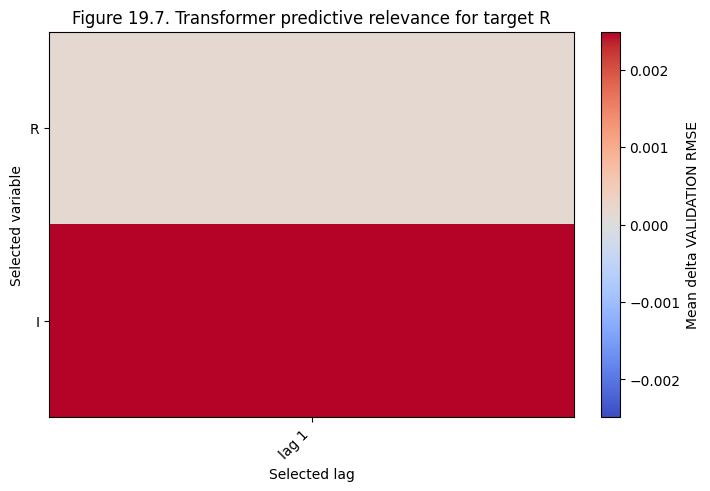

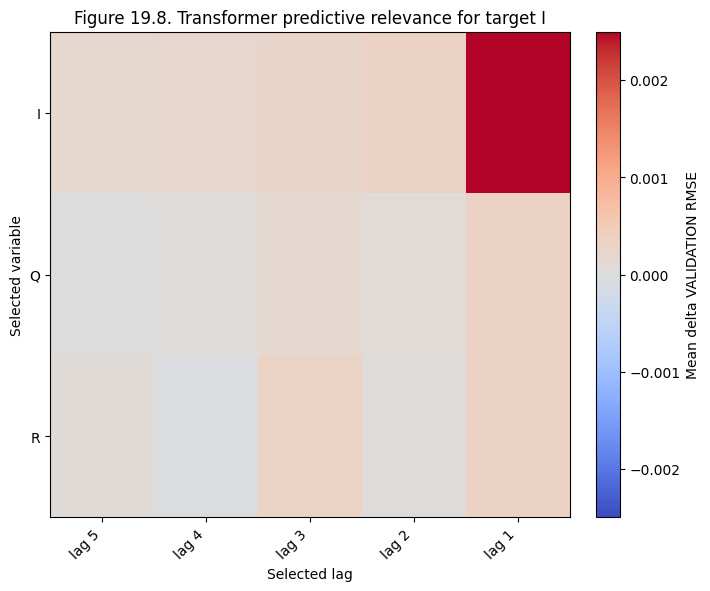

,target,model,importance_scope,parent_block,lag,feature,n_repeats,baseline_RMSE,mean_delta_RMSE,median_delta_RMSE,validation_only
0,R,RF,PARENT_BLOCK,R,NaN,R_BLOCK,20,0.006241,0.000491,0.000489,True
1,R,RF,PARENT_BLOCK,I,NaN,I_BLOCK,20,0.006241,0.002001,0.002042,True
3,I,RF,PARENT_BLOCK,I,NaN,I_BLOCK,20,0.004501,0.006030,0.006029,True
6,R,GB,PARENT_BLOCK,R,NaN,R_BLOCK,20,0.004955,0.000294,0.000289,True
7,R,GB,PARENT_BLOCK,I,NaN,I_BLOCK,20,0.004955,0.002937,0.002977,True
10,I,GB,PARENT_BLOCK,I,NaN,I_BLOCK,20,0.005183,0.005218,0.005230,True
13,R,MLP,PARENT_BLOCK,R,NaN,R_BLOCK,20,0.006145,0.000209,0.000242,True
14,R,MLP,PARENT_BLOCK,I,NaN,I_BLOCK,20,0.006145,0.002693,0.002725,True
16,I,MLP,PARENT_BLOCK,I,NaN,I_BLOCK,20,0.004192,0.005953,0.005963,True
17,I,MLP,PARENT_BLOCK,Q,NaN,Q_BLOCK,20,0.004192,0.000484,0.000499,True


In [13]:
PERMUTATION_REPEATS = 20
TRANSFORMER_FEATURE_REPEATS = 30
importance_rows = []
rng = np.random.default_rng(19)

for model in (() if REUSE_FROZEN_SELECTION else MODEL_FAMILIES):
    for target in TARGETS:
        parents, lag_order = selected_structure(model, target)
        columns = feature_columns(parents, lag_order)
        frame = validation_fit_frames[(model, target)]
        original = frame[columns].to_numpy(dtype=float)
        actual = frame[target].to_numpy(dtype=float)
        baseline = compute_metrics(actual, validation_prediction(model, target, original))["RMSE"]

        for state in parents:
            indices = [index for index, column in enumerate(columns) if column.startswith(state + "_lag")]
            deltas = []
            for _ in range(PERMUTATION_REPEATS):
                permutation = rng.permutation(len(frame))
                permuted = original.copy()
                permuted[:, indices] = original[permutation][:, indices]
                permuted_frame = pd.DataFrame(permuted, columns=columns, index=frame.index)
                rmse = compute_metrics(actual, validation_prediction(model, target, permuted_frame))["RMSE"]
                deltas.append(rmse - baseline)
            importance_rows.append({
                "target": target, "model": model, "importance_scope": "PARENT_BLOCK",
                "parent_block": state, "lag": np.nan, "feature": state + "_BLOCK",
                "n_repeats": len(deltas), "baseline_RMSE": baseline,
                "mean_delta_RMSE": float(np.mean(deltas)),
                "median_delta_RMSE": float(np.median(deltas)),
                "validation_only": True,
            })

        for lag in range(1, lag_order + 1):
            indices = [index for index, column in enumerate(columns) if column.endswith(f"_lag{lag}")]
            deltas = []
            for _ in range(PERMUTATION_REPEATS):
                permutation = rng.permutation(len(frame))
                permuted = original.copy()
                permuted[:, indices] = original[permutation][:, indices]
                permuted_frame = pd.DataFrame(permuted, columns=columns, index=frame.index)
                rmse = compute_metrics(actual, validation_prediction(model, target, permuted_frame))["RMSE"]
                deltas.append(rmse - baseline)
            importance_rows.append({
                "target": target, "model": model, "importance_scope": "LAG_GROUP",
                "parent_block": "|".join(parents), "lag": lag, "feature": f"LAG_{lag}",
                "n_repeats": len(deltas), "baseline_RMSE": baseline,
                "mean_delta_RMSE": float(np.mean(deltas)),
                "median_delta_RMSE": float(np.median(deltas)),
                "validation_only": True,
            })

        if model == "TRANSFORMER":
            for index, column in enumerate(columns):
                state, lag_text = column.split("_lag")
                deltas = []
                for _ in range(TRANSFORMER_FEATURE_REPEATS):
                    permutation = rng.permutation(len(frame))
                    permuted = original.copy()
                    permuted[:, index] = original[permutation, index]
                    permuted_frame = pd.DataFrame(permuted, columns=columns, index=frame.index)
                    rmse = compute_metrics(actual, validation_prediction(model, target, permuted_frame))["RMSE"]
                    deltas.append(rmse - baseline)
                importance_rows.append({
                    "target": target, "model": model, "importance_scope": "INDIVIDUAL_FEATURE",
                    "parent_block": state, "lag": int(lag_text), "feature": column,
                    "n_repeats": len(deltas), "baseline_RMSE": baseline,
                    "mean_delta_RMSE": float(np.mean(deltas)),
                    "median_delta_RMSE": float(np.median(deltas)),
                    "validation_only": True,
                })

predictive_relevance_validation = pd.read_csv(PROCESSED / "19_predictive_relevance_validation.csv") if REUSE_FROZEN_SELECTION else pd.DataFrame(importance_rows)
assert predictive_relevance_validation["validation_only"].all()

for target, filename, number in [
    ("R", "19_figure_19_7_transformer_predictive_relevance_R.png", 7),
    ("I", "19_figure_19_8_transformer_predictive_relevance_I.png", 8),
]:
    parents, lag_order = selected_structure("TRANSFORMER", target)
    rows = predictive_relevance_validation.loc[
        predictive_relevance_validation["target"].eq(target)
        & predictive_relevance_validation["model"].eq("TRANSFORMER")
        & predictive_relevance_validation["importance_scope"].eq("INDIVIDUAL_FEATURE")
    ]
    matrix = rows.pivot(index="parent_block", columns="lag", values="mean_delta_RMSE").reindex(
        index=list(parents), columns=list(range(lag_order, 0, -1))
    )
    limit = max(float(np.nanmax(np.abs(matrix.to_numpy()))), 1e-12)
    fig, ax = plt.subplots(figsize=(max(7, lag_order * 0.75), 2.8 + len(parents)), constrained_layout=True)
    image = ax.imshow(matrix.to_numpy(), aspect="auto", cmap="coolwarm", vmin=-limit, vmax=limit)
    ax.set_xticks(range(lag_order), [f"lag {lag}" for lag in range(lag_order, 0, -1)], rotation=45, ha="right")
    ax.set_yticks(range(len(parents)), parents)
    ax.set_title(f"Figure 19.{number}. Transformer predictive relevance for target {target}")
    ax.set_xlabel("Selected lag")
    ax.set_ylabel("Selected variable")
    fig.colorbar(image, ax=ax, label="Mean delta VALIDATION RMSE")
    save_figure(fig, filename)

display(predictive_relevance_validation.loc[predictive_relevance_validation["importance_scope"].eq("PARENT_BLOCK")])

The relevance tables are conditional on each already-selected model. Positive delta RMSE indicates that shuffling a retained block or lag worsened VALIDATION forecasts; negative values indicate that the fitted model did not benefit reliably from that component in this diagnostic.

## 19.7 Step 3 — eventless refitting with frozen specifications

Corrected N18 masks enter for the first time here. Parent blocks, lag orders, hyperparameters, seeds, scaling method, and neural epoch counts remain unchanged.

For VALIDATION backgrounds, event-age-0 target observations are removed only from TRAIN fitting targets. For TEST backgrounds, they are removed only from TRAIN+VALIDATION fitting targets. The chronology and lagged Q/R/I histories remain intact, so observed event states can legitimately appear as later predictors.

In [14]:
assert SPECIFICATIONS_FROZEN and STRUCTURES_FROZEN
spec_18 = pd.read_csv(PROCESSED / "18_primary_specification.csv").iloc[0]
event_flags = pd.read_csv(PROCESSED / "18_event_day_flags.csv", parse_dates=["model_day"])
target_specific_mapping = pd.read_csv(
    PROCESSED / "18_target_specific_event_mapping.csv",
    parse_dates=["realised_model_day", "implied_model_day", "target_model_day", "model_day", "event_timestamp_utc"],
)
n18_event_weights = pd.read_csv(
    PROCESSED / "18_event_response_weights.csv",
    parse_dates=["realised_model_day", "implied_model_day", "target_model_day", "model_day", "event_timestamp_utc"],
)

assert as_bool(spec_18["timing_audit_completed"])
assert str(spec_18["timing_audit_notebook"]) == "18A_implied_event_timing_audit.ipynb"
assert str(spec_18["implied_timing_rule"]) == "last_defensible_daily_IV_observation_preceding_announcement"
assert {"FOMC": 0, "US Employment": -1, "US CPI": -1, "BoJ": -1, "JPY National CPI": -1, "JPY GDP": -1} == {family: int(spec_18[f"{family.replace(' ', '_')}_implied_offset"]) for family in FAMILIES}
assert str(spec_18["minus_one_definition"]) == "previous_observed_canonical_model_day_row"
assert not as_bool(spec_18["bloomberg_snapshot_time_identified"])
assert str(spec_18["implied_event_alignment"]) == "FAMILY_SPECIFIC_LAST_DEFENSIBLE_PRE_ANNOUNCEMENT_IV_OBSERVATION"
assert not as_bool(spec_18["linus_equation_5_used"])
assert target_specific_mapping.loc[target_specific_mapping["target"].eq("R"), "target_model_day"].eq(
    target_specific_mapping.loc[target_specific_mapping["target"].eq("R"), "realised_model_day"]
).all()
assert target_specific_mapping.loc[target_specific_mapping["target"].eq("I"), "target_model_day"].eq(
    target_specific_mapping.loc[target_specific_mapping["target"].eq("I"), "implied_model_day"]
).all()
assert target_specific_mapping.loc[target_specific_mapping["family"].eq("FOMC"), "implied_event_offset"].eq(0).all()
assert target_specific_mapping.loc[~target_specific_mapping["family"].eq("FOMC"), "implied_event_offset"].eq(-1).all()
canonical_row = pd.Series(np.arange(len(panel)), index=panel["model_day"].to_numpy())
implied_rows = target_specific_mapping["implied_model_day"].map(canonical_row)
realised_rows = target_specific_mapping["realised_model_day"].map(canonical_row)
minus_one = target_specific_mapping["implied_event_offset"].eq(-1)
assert implied_rows.loc[minus_one].eq(realised_rows.loc[minus_one] - 1).all()

flag_columns = [
    "model_day",
    "R_is_target_event_day", "R_is_clean_single_family", "R_is_overlap",
    "R_n_target_occurrences", "R_n_target_families", "R_family_set",
    "I_is_target_event_day", "I_is_clean_single_family", "I_is_overlap",
    "I_n_target_occurrences", "I_n_target_families", "I_family_set",
]
panel = panel.merge(event_flags[flag_columns], on="model_day", how="left", validate="one_to_one")
for target in TARGETS:
    for suffix in ["is_target_event_day", "is_clean_single_family", "is_overlap"]:
        panel[f"{target}_{suffix}"] = panel[f"{target}_{suffix}"].eq(True)
    for suffix in ["n_target_occurrences", "n_target_families"]:
        panel[f"{target}_{suffix}"] = pd.to_numeric(panel[f"{target}_{suffix}"], errors="coerce").fillna(0).astype(int)
    panel[f"{target}_family_set"] = panel[f"{target}_family_set"].fillna("")
assert panel[["model_day", *MAX_LAG_FEATURES]].equals(lag_snapshot)

for target in TARGETS:
    event_indices = panel.index[panel[f"{target}_is_target_event_day"]]
    event_indices = event_indices[event_indices < len(panel) - 1]
    for state in STATES:
        previous = panel.loc[event_indices, state].to_numpy(dtype=float)
        following_lag = panel.loc[event_indices + 1, f"{state}_lag1"].to_numpy(dtype=float)
        finite = np.isfinite(previous) & np.isfinite(following_lag)
        assert np.allclose(previous[finite], following_lag[finite])

def eventless_calibration(target, splits, parents, lag_order):
    frames = [model_frame(target, split, parents, lag_order) for split in splits]
    ordinary = pd.concat(frames, ignore_index=True).sort_values("model_day")
    eventless = ordinary.loc[~ordinary[f"{target}_is_target_event_day"]].copy()
    return ordinary, eventless

def build_eventless_forecasts(prediction_split):
    records = []
    audits = []
    calibration_splits = ("train",) if prediction_split == "validation" else ("train", "validation")
    stage = "EVENTLESS_TRAIN_TO_VALIDATION" if prediction_split == "validation" else "EVENTLESS_TRAIN_VALIDATION_TO_TEST"
    for model in MODEL_FAMILIES:
        for target in TARGETS:
            parents, lag_order = selected_structure(model, target)
            ordinary_fit, eventless_fit = eventless_calibration(target, calibration_splits, parents, lag_order)
            prediction_frame = model_frame(target, prediction_split, parents, lag_order)
            prediction = frozen_fit_predict(model, target, eventless_fit, prediction_frame)
            audits.append({
                "model": model, "target": target, "forecast_stage": stage,
                "calibration_splits": "|".join(calibration_splits),
                "ordinary_eligible_n": len(ordinary_fit),
                "removed_target_events_n": int(ordinary_fit[f"{target}_is_target_event_day"].sum()),
                "eventless_fit_n": len(eventless_fit),
                "prediction_n": len(prediction_frame),
                "structure_frozen": True, "hyperparameters_frozen": True,
            })
            for row, value in zip(prediction_frame.itertuples(index=False), prediction):
                records.append({
                    "model_day": row.model_day, "target_model_day": row.model_day,
                    "sample_split": prediction_split, "forecast_stage": stage,
                    "target": target, "model": model, "actual": float(getattr(row, target)),
                    "raw_background_forecast": float(value),
                    "admissible_background_forecast": float(admissible_forecast([value], target)[0]),
                    "background_forecast": float(admissible_forecast([value], target)[0]),
                    "forecast_floor": FROZEN_TARGET_FLOORS[target],
                    "floor_activated": bool(np.isfinite(value) and value < FROZEN_TARGET_FLOORS[target]),
                    "is_out_of_sample": True,
                    "is_target_event_day": bool(getattr(row, f"{target}_is_target_event_day")),
                    "is_clean_single_family": bool(getattr(row, f"{target}_is_clean_single_family")),
                    "is_overlap": bool(getattr(row, f"{target}_is_overlap")),
                    "n_target_occurrences": int(getattr(row, f"{target}_n_target_occurrences")),
                    "n_target_families": int(getattr(row, f"{target}_n_target_families")),
                    "family_set": getattr(row, f"{target}_family_set"),
                })
    return pd.DataFrame(records), pd.DataFrame(audits)

eventless_forecasts_validation, eventless_audit_validation = build_eventless_forecasts("validation")
eventless_forecasts_test, eventless_audit_test = build_eventless_forecasts("test")
eventless_support_audit = pd.concat([eventless_audit_validation, eventless_audit_test], ignore_index=True)
assert eventless_support_audit["structure_frozen"].all()
assert eventless_support_audit["hyperparameters_frozen"].all()
assert (eventless_support_audit["ordinary_eligible_n"] - eventless_support_audit["removed_target_events_n"] == eventless_support_audit["eventless_fit_n"]).all()
eventless_admissibility_audit = forecast_admissibility_audit(pd.concat([eventless_forecasts_validation, eventless_forecasts_test], ignore_index=True).rename(columns={"raw_background_forecast": "raw_forecast", "admissible_background_forecast": "admissible_forecast"}), "EVENTLESS_BACKGROUND")
display(eventless_support_audit)
display(eventless_admissibility_audit)

,model,target,forecast_stage,calibration_splits,ordinary_eligible_n,removed_target_events_n,eventless_fit_n,prediction_n,structure_frozen,hyperparameters_frozen
0,RF,R,EVENTLESS_TRAIN_TO_VALIDATION,train,3005,684,2321,1181,True,True
1,RF,I,EVENTLESS_TRAIN_TO_VALIDATION,train,3015,703,2312,1209,True,True
2,GB,R,EVENTLESS_TRAIN_TO_VALIDATION,train,2782,641,2141,1168,True,True
3,GB,I,EVENTLESS_TRAIN_TO_VALIDATION,train,3015,703,2312,1209,True,True
4,MLP,R,EVENTLESS_TRAIN_TO_VALIDATION,train,3005,684,2321,1181,True,True
5,MLP,I,EVENTLESS_TRAIN_TO_VALIDATION,train,2554,586,1968,1155,True,True
6,TRANSFORMER,R,EVENTLESS_TRAIN_TO_VALIDATION,train,3005,684,2321,1181,True,True
7,TRANSFORMER,I,EVENTLESS_TRAIN_TO_VALIDATION,train,2497,576,1921,1143,True,True
8,RF,R,EVENTLESS_TRAIN_VALIDATION_TO_TEST,train|validation,4186,946,3240,1182,True,True
9,RF,I,EVENTLESS_TRAIN_VALIDATION_TO_TEST,train|validation,4224,967,3257,1208,True,True


,forecast_scope,sample_split,target,model,eligible_forecast_n,raw_negative_n,raw_zero_n,raw_positive_below_floor_n,floor_activated_n,floor_activation_rate
0,EVENTLESS_BACKGROUND,test,I,GB,1208,2,0,0,2,0.001656
1,EVENTLESS_BACKGROUND,test,I,MLP,1156,0,0,0,0,0.000000
2,EVENTLESS_BACKGROUND,test,I,RF,1208,0,0,0,0,0.000000
3,EVENTLESS_BACKGROUND,test,I,TRANSFORMER,1142,0,0,10,10,0.008757
4,EVENTLESS_BACKGROUND,test,R,GB,1169,0,0,0,0,0.000000
5,EVENTLESS_BACKGROUND,test,R,MLP,1182,0,0,0,0,0.000000
6,EVENTLESS_BACKGROUND,test,R,RF,1182,0,0,0,0,0.000000
7,EVENTLESS_BACKGROUND,test,R,TRANSFORMER,1182,0,0,0,0,0.000000
8,EVENTLESS_BACKGROUND,validation,I,GB,1209,0,0,0,0,0.000000
9,EVENTLESS_BACKGROUND,validation,I,MLP,1155,0,0,0,0,0.000000


## 19.8 Ordinary ratios, clean TEST event weights, and robustness

Raw ratios are diagnostics: they are defined only with finite positive raw denominators. Canonical production ratios and event weights instead divide the unchanged observed target by the frozen-floor admissible forecast or eventless background. No target or event weight is clipped.

The clean TEST comparison inherits N18's authoritative parametric raw/admissible fields directly; flexible models retain the same distinction.


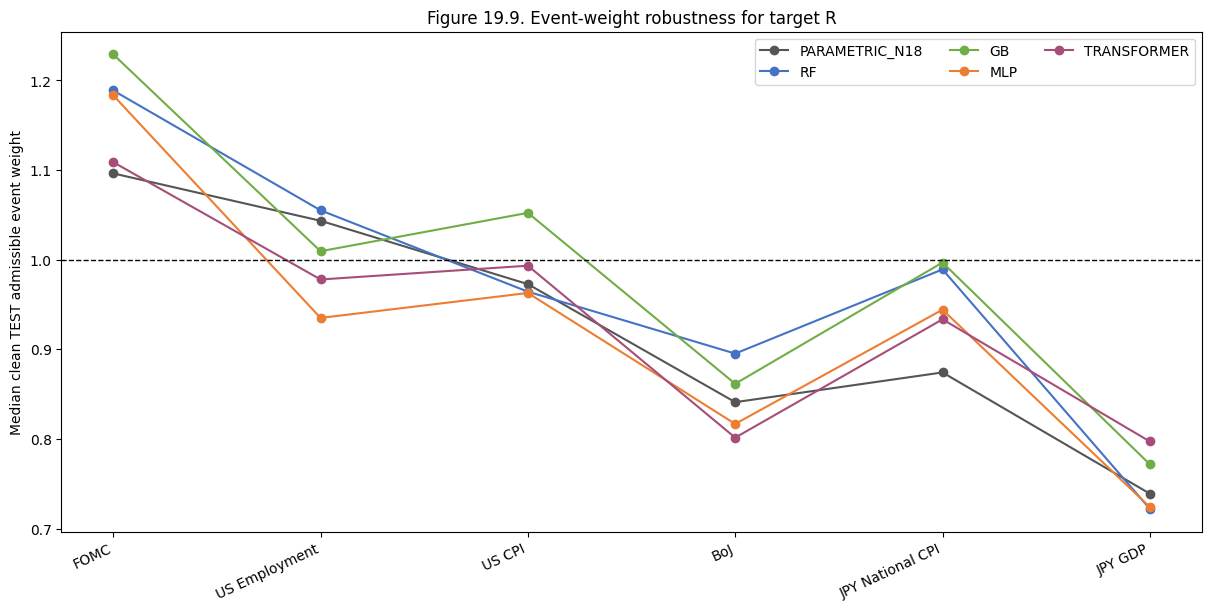

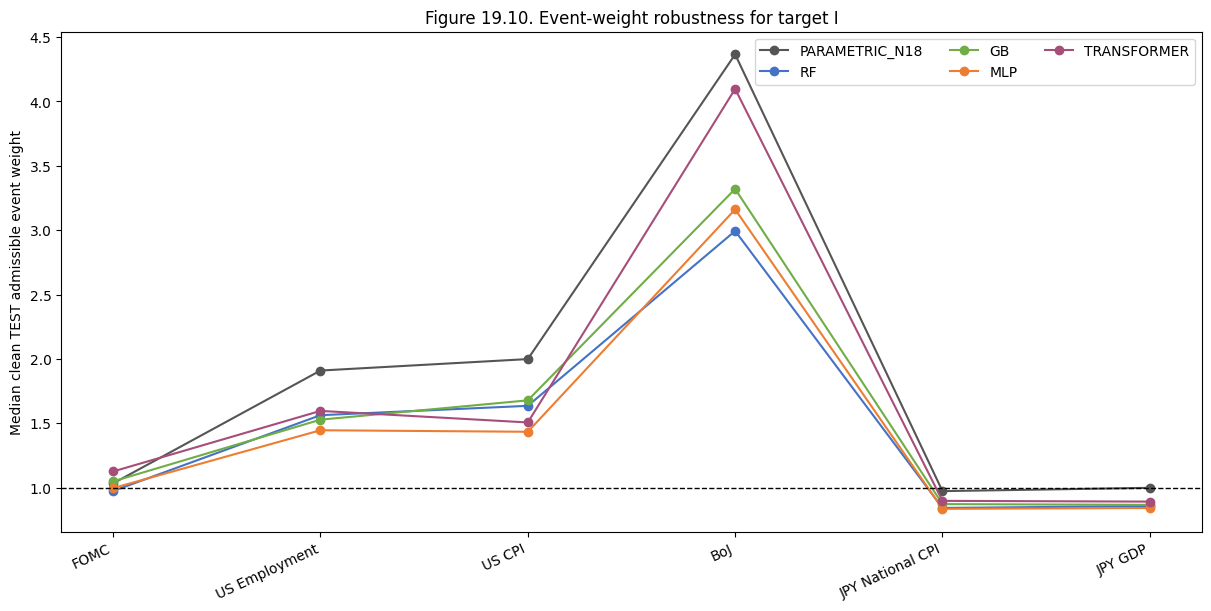

,model,target,targeted_event_n,equation_eligible_n,clean_primary_event_n,raw_positive_denominator_n,admissible_weight_defined_n,floor_activated_n,clean_event_floor_activated_n
0,GB,I,275,275,243,274,275,1,1
1,GB,R,276,273,248,273,273,0,0
2,MLP,I,275,268,243,268,268,0,0
3,MLP,R,276,274,248,274,274,0,0
4,PARAMETRIC_N18,I,275,250,243,238,250,17,17
5,PARAMETRIC_N18,R,276,274,248,274,274,0,0
6,RF,I,275,275,243,275,275,0,0
7,RF,R,276,274,248,274,274,0,0
8,TRANSFORMER,I,275,265,243,265,265,0,0
9,TRANSFORMER,R,276,274,248,274,274,0,0


,family,target,occurrence_n,clean_test_occurrence_n,overlap_occurrence_n,effective_model_valid_support_min,effective_model_valid_support_max,effective_model_raw_support_min,effective_model_raw_support_max
0,BoJ,I,37,24,13,24,24,23,24
1,BoJ,R,37,27,10,26,27,26,27
2,FOMC,I,37,32,5,30,32,30,32
3,FOMC,R,37,34,3,33,33,33,33
4,JPY GDP,I,37,35,2,30,35,28,35
5,JPY GDP,R,38,36,2,36,36,36,36
6,JPY National CPI,I,56,48,8,45,48,42,48
7,JPY National CPI,R,56,48,8,47,47,47,47
8,US CPI,I,54,52,2,45,52,43,52
9,US CPI,R,54,51,3,51,51,51,51


,target,comparator_model,matched_clean_event_n,admissible_background_correlation,median_absolute_background_difference,median_relative_background_difference,canonical_event_weight_correlation,observed_numerator_exactly_same
0,R,RF,246,0.903987,0.001134,0.142679,0.949782,True
1,R,GB,245,0.949247,0.001021,0.115814,0.986435,True
2,R,MLP,246,0.977074,0.000618,0.071953,0.993836,True
3,R,TRANSFORMER,246,0.983806,0.000903,0.110862,0.992358,True
4,I,RF,220,0.621198,0.002137,0.252564,0.665104,True
5,I,GB,220,0.643438,0.002280,0.267982,0.290806,True
6,I,MLP,220,0.647142,0.002333,0.278433,0.646835,True
7,I,TRANSFORMER,220,0.676041,0.002158,0.245082,0.624499,True


In [15]:
# Ordinary ratios retain the raw diagnostic and make the admissible ratio canonical.
ordinary_response_ratios = pd.concat([event_unaware_forecasts_validation, event_unaware_forecasts_test], ignore_index=True)
ordinary_response_ratios["target_model_day"] = ordinary_response_ratios["model_day"]
for target in TARGETS:
    mask = ordinary_response_ratios["target"].eq(target)
    ordinary_response_ratios.loc[mask, "known_event_target_flag"] = ordinary_response_ratios.loc[mask, "model_day"].map(panel.set_index("model_day")[f"{target}_is_target_event_day"])
ordinary_response_ratios["known_event_target_flag"] = ordinary_response_ratios["known_event_target_flag"].eq(True)
ordinary_response_ratios["ordinary_flag"] = ~ordinary_response_ratios["known_event_target_flag"]
ordinary_response_ratios["equation_eligible"] = np.isfinite(ordinary_response_ratios["actual"]) & np.isfinite(ordinary_response_ratios["admissible_forecast"])
ordinary_response_ratios["raw_positive_background"] = ordinary_response_ratios["equation_eligible"] & ordinary_response_ratios["raw_forecast"].gt(0)
ordinary_response_ratios["background_positive"] = ordinary_response_ratios["equation_eligible"] & ordinary_response_ratios["admissible_forecast"].gt(0)
ordinary_response_ratios["ordinary_response_ratio_raw"] = np.where(ordinary_response_ratios["raw_positive_background"], ordinary_response_ratios["actual"] / ordinary_response_ratios["raw_forecast"], np.nan)
ordinary_response_ratios["ordinary_response_ratio_adm"] = np.where(ordinary_response_ratios["background_positive"], ordinary_response_ratios["actual"] / ordinary_response_ratios["admissible_forecast"], np.nan)
ordinary_response_ratios["response_ratio"] = ordinary_response_ratios["ordinary_response_ratio_adm"]
ordinary_response_ratios["background_forecast"] = ordinary_response_ratios["admissible_forecast"]
ordinary_response_ratios = ordinary_response_ratios[[
    "model_day", "target_model_day", "sample_split", "forecast_stage", "target", "model", "actual", "raw_forecast", "admissible_forecast", "background_forecast", "forecast_floor", "floor_activated", "ordinary_response_ratio_raw", "ordinary_response_ratio_adm", "response_ratio", "raw_positive_background", "background_positive", "equation_eligible", "known_event_target_flag", "ordinary_flag", "is_out_of_sample",
]]

mapping_columns = ["event_id", "event_label", "family", "event_timestamp_utc", "event_timestamp_ny", "realised_model_day", "implied_model_day", "target", "target_model_day", "sample_split", "is_clean_single_family", "is_overlap", "n_target_occurrences"]
test_mapping = target_specific_mapping.loc[target_specific_mapping["sample_split"].eq("test"), mapping_columns].copy()
assert set(test_mapping["family"]) == set(FAMILIES)
flexible_event_parts = []
for target in TARGETS:
    occurrences = test_mapping.loc[test_mapping["target"].eq(target)].copy()
    occurrences["_key"] = 1
    cartesian = occurrences.merge(pd.DataFrame({"model": MODEL_FAMILIES, "_key": 1}), on="_key").drop(columns="_key")
    source = eventless_forecasts_test.loc[eventless_forecasts_test["target"].eq(target), ["target_model_day", "target", "model", "actual", "raw_background_forecast", "admissible_background_forecast", "forecast_floor", "floor_activated", "forecast_stage", "is_out_of_sample"]]
    cartesian = cartesian.merge(source, on=["target_model_day", "target", "model"], how="left", validate="many_to_one")
    cartesian["actual"] = cartesian["actual"].fillna(cartesian["target_model_day"].map(panel.set_index("model_day")[target]))
    cartesian["forecast_stage"] = cartesian["forecast_stage"].fillna("EVENTLESS_TRAIN_VALIDATION_TO_TEST")
    cartesian["is_out_of_sample"] = True
    cartesian["equation_eligible"] = np.isfinite(cartesian["actual"]) & np.isfinite(cartesian["admissible_background_forecast"])
    cartesian["raw_background_positive"] = cartesian["equation_eligible"] & cartesian["raw_background_forecast"].gt(0)
    cartesian["background_positive"] = cartesian["equation_eligible"] & cartesian["admissible_background_forecast"].gt(0)
    cartesian["raw_weight_defined"] = cartesian["raw_background_positive"]
    cartesian["weight_defined"] = cartesian["background_positive"]
    cartesian["event_weight_raw"] = np.where(cartesian["raw_weight_defined"], cartesian["actual"] / cartesian["raw_background_forecast"], np.nan)
    cartesian["event_weight_adm"] = np.where(cartesian["weight_defined"], cartesian["actual"] / cartesian["admissible_background_forecast"], np.nan)
    cartesian["event_weight"] = cartesian["event_weight_adm"]
    cartesian["response_ratio"] = cartesian["event_weight_adm"]
    cartesian["undefined_reason"] = np.select([~cartesian["equation_eligible"], cartesian["equation_eligible"] & ~cartesian["background_positive"]], ["not_equation_eligible", "nonpositive_admissible_background"], default="")
    cartesian["raw_weight_undefined_reason"] = np.select([~cartesian["equation_eligible"], cartesian["equation_eligible"] & ~cartesian["raw_background_positive"]], ["not_equation_eligible", "nonpositive_raw_background"], default="")
    flexible_event_parts.append(cartesian)

flexible_event_weights = pd.concat(
    flexible_event_parts,
    ignore_index=True,
)

# Canonical production background is the admissible variance forecast.
# Keep the raw background separately for diagnostics.
flexible_event_weights["background_forecast"] = (
    flexible_event_weights["admissible_background_forecast"]
)

parametric = n18_event_weights.loc[
    n18_event_weights["sample_split"].eq("test")
].copy()

required_n18 = {"raw_background_forecast", "admissible_background_forecast", "floor_activated", "event_weight_raw", "event_weight_adm", "event_weight", "raw_weight_defined", "weight_defined"}
assert required_n18.issubset(parametric.columns)
assert np.allclose(parametric["event_weight"], parametric["event_weight_adm"], equal_nan=True)
parametric["model"] = "PARAMETRIC_N18"
parametric["background_forecast"] = parametric["admissible_background_forecast"]
parametric["forecast_stage"] = "AUTHORITATIVE_N18_EVENTLESS_TEST"
parametric["is_out_of_sample"] = True
parametric["undefined_reason"] = parametric["undefined_reason"].fillna("")
parametric["raw_weight_undefined_reason"] = parametric["raw_weight_undefined_reason"].fillna("")

event_weight_columns = [*mapping_columns, "model", "actual", "raw_background_forecast", "admissible_background_forecast", "background_forecast", "forecast_floor", "floor_activated", "forecast_stage", "is_out_of_sample", "equation_eligible", "raw_background_positive", "background_positive", "raw_weight_defined", "weight_defined", "event_weight_raw", "event_weight_adm", "event_weight", "response_ratio", "undefined_reason", "raw_weight_undefined_reason"]
event_response_weights = pd.concat([parametric[event_weight_columns], flexible_event_weights[event_weight_columns]], ignore_index=True)
assert event_response_weights["sample_split"].eq("test").all()
assert event_response_weights["event_weight"].equals(event_response_weights["event_weight_adm"])
assert event_response_weights.loc[~event_response_weights["raw_weight_defined"].eq(True), "event_weight_raw"].isna().all()
defined = event_response_weights["weight_defined"].eq(True)
assert np.allclose(event_response_weights.loc[defined, "event_weight"], event_response_weights.loc[defined, "actual"] / event_response_weights.loc[defined, "admissible_background_forecast"], rtol=1e-12, atol=1e-14)

# Verify that every equation-eligible flexible event row uses the
# eventless background generated by its own fitted model.
#
# The full event-weight table deliberately retains targeted events that
# are not equation-eligible for a particular flexible specification.
# Those rows have no corresponding entry in eventless_forecasts_test
# and must therefore remain NaN rather than being treated as errors.
for model in MODEL_FAMILIES:

    expected = eventless_forecasts_test.loc[
        eventless_forecasts_test["model"].eq(model),
        [
            "target_model_day",
            "target",
            "model",
            "raw_background_forecast",
            "admissible_background_forecast",
        ],
    ].drop_duplicates()

    observed = event_response_weights.loc[
        event_response_weights["model"].eq(model),
        [
            "event_id",
            "target_model_day",
            "target",
            "model",
            "equation_eligible",
            "raw_background_forecast",
            "admissible_background_forecast",
        ],
    ].copy()

    checked = observed.merge(
        expected,
        on=["target_model_day", "target", "model"],
        how="left",
        suffixes=("_event", "_source"),
        validate="many_to_one",
        indicator=True,
    )

    matched = checked["_merge"].eq("both")
    unmatched = checked["_merge"].eq("left_only")

    # Every equation-eligible event must have a corresponding
    # eventless forecast from that same flexible model.
    assert checked.loc[
        checked["equation_eligible"].eq(True),
        "_merge",
    ].eq("both").all()

    # Any event without a source forecast must genuinely be
    # equation-ineligible for that model.
    assert checked.loc[
        unmatched,
        "equation_eligible",
    ].eq(False).all()

    # Ineligible event rows must not contain fabricated backgrounds.
    assert checked.loc[
        unmatched,
        [
            "raw_background_forecast_event",
            "admissible_background_forecast_event",
        ],
    ].isna().all().all()

    # For matched rows, the event-weight calculation must use exactly
    # that model's own eventless fitted background.
    assert np.allclose(
        checked.loc[matched, "raw_background_forecast_event"],
        checked.loc[matched, "raw_background_forecast_source"],
        equal_nan=True,
    )

    assert np.allclose(
        checked.loc[matched, "admissible_background_forecast_event"],
        checked.loc[matched, "admissible_background_forecast_source"],
        equal_nan=True,
    )

clean = event_response_weights.loc[event_response_weights["is_clean_single_family"].eq(True)].copy()
summary_rows = []
for (family, target, model), group in clean.groupby(["family", "target", "model"], sort=True):
    valid = group.loc[group["weight_defined"].eq(True), "event_weight"].to_numpy(dtype=float)
    raw_valid = group.loc[group["raw_weight_defined"].eq(True), "event_weight_raw"].to_numpy(dtype=float)
    summary_rows.append({"family": family, "target": target, "model": model, "clean_occurrence_n": len(group), "equation_eligible_n": int(group["equation_eligible"].sum()), "raw_positive_background_n": len(raw_valid), "admissible_weight_defined_n": len(valid), "valid_positive_background_n": len(valid), "floor_activated_n": int(group["floor_activated"].sum()), "median_event_weight": float(np.median(valid)) if len(valid) else np.nan, "Q25_event_weight": float(np.quantile(valid, .25)) if len(valid) else np.nan, "Q75_event_weight": float(np.quantile(valid, .75)) if len(valid) else np.nan, "mean_event_weight": float(np.mean(valid)) if len(valid) else np.nan, "raw_median_event_weight": float(np.median(raw_valid)) if len(raw_valid) else np.nan})
event_weight_summary_clean_test = pd.DataFrame(summary_rows)
assert set(event_weight_summary_clean_test["model"]) == set((*MODEL_FAMILIES, "PARAMETRIC_N18"))

event_weight_support_audit = event_response_weights.groupby(["model", "target"], as_index=False).agg(targeted_event_n=("event_id", "size"), equation_eligible_n=("equation_eligible", "sum"), clean_primary_event_n=("is_clean_single_family", "sum"), raw_positive_denominator_n=("raw_weight_defined", "sum"), admissible_weight_defined_n=("weight_defined", "sum"), floor_activated_n=("floor_activated", "sum"))
clean_floor = clean.groupby(["model", "target"], as_index=False).agg(clean_event_floor_activated_n=("floor_activated", "sum"))
event_weight_support_audit = event_weight_support_audit.merge(clean_floor, on=["model", "target"], validate="one_to_one")
event_family_imbalance = test_mapping.groupby(["family", "target"], as_index=False).agg(occurrence_n=("event_id", "size"), clean_test_occurrence_n=("is_clean_single_family", "sum"), overlap_occurrence_n=("is_overlap", "sum")).merge(clean.groupby(["family", "target", "model"], as_index=False).agg(admissible_support=("weight_defined", "sum"), raw_support=("raw_weight_defined", "sum")).groupby(["family", "target"], as_index=False).agg(effective_model_valid_support_min=("admissible_support", "min"), effective_model_valid_support_max=("admissible_support", "max"), effective_model_raw_support_min=("raw_support", "min"), effective_model_raw_support_max=("raw_support", "max")), on=["family", "target"], validate="one_to_one")

agreement_rows, similarity_rows = [], []
benchmark = clean.loc[clean["model"].eq("PARAMETRIC_N18") & clean["weight_defined"].eq(True)]
for target in TARGETS:
    for family in FAMILIES:
        ref = benchmark.loc[benchmark["target"].eq(target) & benchmark["family"].eq(family), ["event_id", "event_weight"]].rename(columns={"event_weight": "parametric_weight"})
        for model in MODEL_FAMILIES:
            comp = clean.loc[clean["target"].eq(target) & clean["family"].eq(family) & clean["model"].eq(model) & clean["weight_defined"].eq(True), ["event_id", "event_weight"]].rename(columns={"event_weight": "flexible_weight"})
            matched = ref.merge(comp, on="event_id", validate="one_to_one")
            pm, fm = (float(np.median(matched[x])) if len(matched) else np.nan for x in ["parametric_weight", "flexible_weight"])
            agreement_rows.append({"target": target, "family": family, "benchmark_model": "PARAMETRIC_N18", "comparator_model": model, "valid_common_n": len(matched), "pearson_correlation": matched["parametric_weight"].corr(matched["flexible_weight"]) if len(matched)>=2 else np.nan, "spearman_correlation": matched["parametric_weight"].corr(matched["flexible_weight"], method="spearman") if len(matched)>=2 else np.nan, "median_absolute_difference": float(np.median(np.abs(matched["flexible_weight"]-matched["parametric_weight"]))) if len(matched) else np.nan, "parametric_family_median": pm, "flexible_family_median": fm, "family_median_same_side_of_one": bool((pm>1)==(fm>1)) if len(matched) else False})
    for model in MODEL_FAMILIES:
        ref = benchmark.loc[benchmark["target"].eq(target), ["event_id", "actual", "admissible_background_forecast", "event_weight"]].rename(columns={"actual":"actual_n18", "admissible_background_forecast":"background_n18", "event_weight":"weight_n18"})
        comp = clean.loc[clean["target"].eq(target) & clean["model"].eq(model) & clean["weight_defined"].eq(True), ["event_id", "actual", "admissible_background_forecast", "event_weight"]].rename(columns={"actual":"actual_flexible", "admissible_background_forecast":"background_flexible", "event_weight":"weight_flexible"})
        matched = ref.merge(comp, on="event_id", validate="one_to_one")
        relative = np.abs(matched["background_flexible"]-matched["background_n18"])/matched["background_n18"]
        similarity_rows.append({"target": target, "comparator_model": model, "matched_clean_event_n": len(matched), "admissible_background_correlation": matched["background_n18"].corr(matched["background_flexible"]) if len(matched)>=2 else np.nan, "median_absolute_background_difference": float(np.median(np.abs(matched["background_flexible"]-matched["background_n18"]))) if len(matched) else np.nan, "median_relative_background_difference": float(np.median(relative)) if len(matched) else np.nan, "canonical_event_weight_correlation": matched["weight_n18"].corr(matched["weight_flexible"]) if len(matched)>=2 else np.nan, "observed_numerator_exactly_same": bool(np.allclose(matched["actual_n18"], matched["actual_flexible"], equal_nan=True))})
event_weight_agreement = pd.DataFrame(agreement_rows)
event_weight_similarity_diagnostic = pd.DataFrame(similarity_rows)
assert event_weight_similarity_diagnostic["observed_numerator_exactly_same"].all()

model_order = ["PARAMETRIC_N18", *MODEL_FAMILIES]
colors = ["#555555", "#4472C4", "#70AD47", "#ED7D31", "#A64D79"]
for target, filename, number in [("R", "19_figure_19_9_event_weight_medians_R.png", 9), ("I", "19_figure_19_10_event_weight_medians_I.png", 10)]:
    fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
    target_summary = event_weight_summary_clean_test.loc[event_weight_summary_clean_test["target"].eq(target)]
    x = np.arange(len(FAMILIES))
    for model, color in zip(model_order, colors):
        rows = target_summary.loc[target_summary["model"].eq(model)].set_index("family").reindex(FAMILIES)
        ax.plot(x, rows["median_event_weight"], marker="o", linewidth=1.5, color=color, label=model)
    ax.axhline(1.0, color="black", linewidth=1, linestyle="--")
    ax.set_xticks(x, FAMILIES, rotation=25, ha="right")
    ax.set_ylabel("Median clean TEST admissible event weight")
    ax.set_title(f"Figure 19.{number}. Event-weight robustness for target {target}")
    ax.legend(ncol=3)
    save_figure(fig, filename)

display(event_weight_support_audit)
display(event_family_imbalance)
display(event_weight_similarity_diagnostic)


The event-weight tables compare like-for-like clean TEST occurrences. N18 is imported as the authoritative parametric raw/admissible benchmark, and flexible models retain the same separation. Canonical family summaries, agreement statistics, and figures use admissible weights; raw weights remain undefined when their raw background is non-positive. Floor activation is retained as a provenance flag, not used to clip targets or event weights. The accompanying background-similarity diagnostic separates the common observed numerator from agreement in eventless denominators.


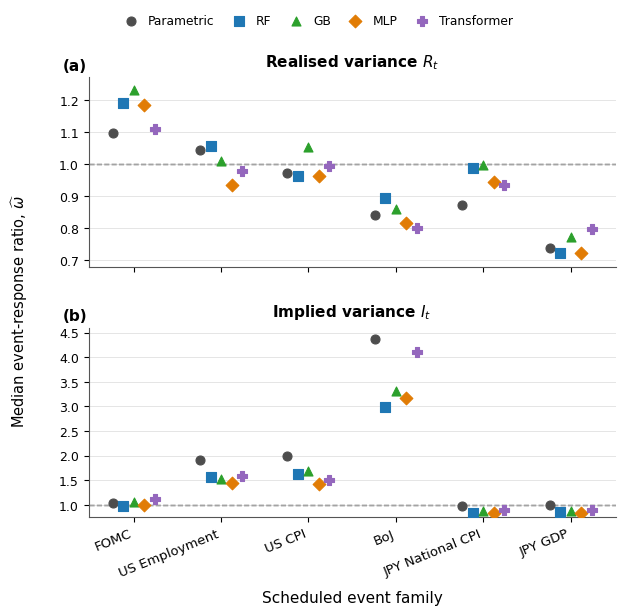

Dissertation figure exported:
  PDF: plots\dissertation\fig_5_3_flexible_event_weight_robustness.pdf
  PNG: plots\dissertation\fig_5_3_flexible_event_weight_robustness.png


In [16]:
# ============================================================
# DISSERTATION FIGURE EXPORT
# Figure 5.3 — Flexible-model event-weight robustness
#
# Presentation only:
# - uses the already-computed `event_weight_summary_clean_test`
# - does NOT recompute event weights
# - does NOT change model selection or admissibility
# ============================================================

from pathlib import Path


# ------------------------------------------------------------
# 1. Output directory
# ------------------------------------------------------------

DISSERTATION_FIG_DIR = Path("plots") / "dissertation"
DISSERTATION_FIG_DIR.mkdir(parents=True, exist_ok=True)

PDF_PATH = (
    DISSERTATION_FIG_DIR
    / "fig_5_3_flexible_event_weight_robustness.pdf"
)

PNG_PATH = (
    DISSERTATION_FIG_DIR
    / "fig_5_3_flexible_event_weight_robustness.png"
)


# ------------------------------------------------------------
# 2. Fixed event-family order
#
# Keep identical to Figure 5.2.
# ------------------------------------------------------------

families = [
    "FOMC",
    "US Employment",
    "US CPI",
    "BoJ",
    "JPY National CPI",
    "JPY GDP",
]


# ------------------------------------------------------------
# 3. Model order and presentation styling
# ------------------------------------------------------------

model_order = [
    "PARAMETRIC_N18",
    "RF",
    "GB",
    "MLP",
    "TRANSFORMER",
]

model_styles = {
    "PARAMETRIC_N18": {
        "label": "Parametric",
        "color": "#4D4D4D",
        "marker": "o",
    },
    "RF": {
        "label": "RF",
        "color": "#1F77B4",
        "marker": "s",
    },
    "GB": {
        "label": "GB",
        "color": "#2CA02C",
        "marker": "^",
    },
    "MLP": {
        "label": "MLP",
        "color": "#E17C05",
        "marker": "D",
    },
    "TRANSFORMER": {
        "label": "Transformer",
        "color": "#9467BD",
        "marker": "P",
    },
}


# ------------------------------------------------------------
# 4. Sanity checks
# ------------------------------------------------------------

required_columns = {
    "family",
    "target",
    "model",
    "median_event_weight",
}

missing_columns = required_columns.difference(
    event_weight_summary_clean_test.columns
)

if missing_columns:
    raise KeyError(
        "`event_weight_summary_clean_test` is missing "
        f"required columns: {missing_columns}"
    )

assert set(families).issubset(
    set(event_weight_summary_clean_test["family"])
)

assert {"R", "I"}.issubset(
    set(event_weight_summary_clean_test["target"])
)

assert set(model_order).issubset(
    set(event_weight_summary_clean_test["model"])
)


# ------------------------------------------------------------
# 5. Create two-panel dissertation figure
#
# Vertical layout preserves readable category labels on A4.
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    1,
    figsize=(6.3, 6.2),
    sharex=True,
)

fig.patch.set_facecolor("white")

x = np.arange(len(families))

# Small horizontal offsets stop the model markers overlapping.
offsets = np.linspace(
    -0.24,
    0.24,
    len(model_order),
)


# ------------------------------------------------------------
# 6. Plot each target
# ------------------------------------------------------------

panel_specs = [
    ("R", r"Realised variance $R_t$"),
    ("I", r"Implied variance $I_t$"),
]

for ax, (target, panel_title) in zip(
    axes,
    panel_specs,
):

    ax.set_facecolor("white")

    target_summary = (
        event_weight_summary_clean_test.loc[
            event_weight_summary_clean_test["target"].eq(target)
        ]
        .copy()
    )

    # --------------------------------------------------------
    # Plot each model as an independent marker
    # --------------------------------------------------------

    for offset, model in zip(
        offsets,
        model_order,
    ):

        style = model_styles[model]

        rows = (
            target_summary.loc[
                target_summary["model"].eq(model)
            ]
            .set_index("family")
            .reindex(families)
        )

        values = rows[
            "median_event_weight"
        ].to_numpy(float)

        ax.scatter(
            x + offset,
            values,
            s=42,
            marker=style["marker"],
            color=style["color"],
            edgecolor=style["color"],
            linewidth=0.8,
            label=style["label"],
            zorder=3,
        )

    # --------------------------------------------------------
    # Reference line
    #
    # omega_hat = 1 means equality with the estimated
    # ordinary background.
    # --------------------------------------------------------

    ax.axhline(
        1.0,
        color="#333333",
        linestyle="--",
        linewidth=1.0,
        zorder=1,
    )

    # --------------------------------------------------------
    # Panel title
    # --------------------------------------------------------

    ax.set_title(
        panel_title,
        fontsize=11,
        fontweight="bold",
        pad=8,
    )

    # --------------------------------------------------------
    # Tick formatting
    # --------------------------------------------------------

    ax.tick_params(
        axis="y",
        labelsize=9,
    )

    # --------------------------------------------------------
    # Light horizontal gridlines only
    # --------------------------------------------------------

    ax.grid(
        axis="y",
        color="#D9D9D9",
        linewidth=0.7,
        alpha=0.7,
    )

    ax.grid(
        axis="x",
        visible=False,
    )

    # --------------------------------------------------------
    # Clean frame
    # --------------------------------------------------------

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color("#555555")
    ax.spines["bottom"].set_color("#555555")

    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)


# ------------------------------------------------------------
# 7. Panel-specific y-axis ranges
#
# Deliberately different because realised responses cluster
# tightly around 1 whereas implied responses span above 4.
# ------------------------------------------------------------

axes[0].set_ylim(
    0.68,
    1.27,
)

axes[0].set_yticks(
    [
        0.7,
        0.8,
        0.9,
        1.0,
        1.1,
        1.2,
    ]
)

axes[1].set_ylim(
    0.75,
    4.6,
)

axes[1].set_yticks(
    [
        1.0,
        1.5,
        2.0,
        2.5,
        3.0,
        3.5,
        4.0,
        4.5,
    ]
)


# ------------------------------------------------------------
# 8. Shared y-axis label
# ------------------------------------------------------------

fig.supylabel(
    r"Median event-response ratio, $\widehat{\omega}$",
    fontsize=10.5,
    x=0.015,
)


# ------------------------------------------------------------
# 9. X-axis labels
# ------------------------------------------------------------

axes[1].set_xticks(x)

axes[1].set_xticklabels(
    families,
    rotation=22,
    ha="right",
    fontsize=9.5,
)

axes[1].set_xlabel(
    "Scheduled event family",
    fontsize=11,
    labelpad=8,
)


# ------------------------------------------------------------
# 10. One shared legend
# ------------------------------------------------------------

handles, labels = (
    axes[0].get_legend_handles_labels()
)

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.995),
    ncol=5,
    frameon=False,
    fontsize=8.8,
    handletextpad=0.4,
    columnspacing=1.0,
)


# ------------------------------------------------------------
# 11. Panel labels
#
# Place inside the upper-left corner of each panel so that
# they do not collide with the y-axis label.
# ------------------------------------------------------------

axes[0].text(
    -0.05,
    1.1,
    "(a)",
    transform=axes[0].transAxes,
    fontsize=11,
    fontweight="bold",
    ha="left",
    va="top",
)

axes[1].text(
    -0.05,
    1.1,
    "(b)",
    transform=axes[1].transAxes,
    fontsize=11,
    fontweight="bold",
    ha="left",
    va="top",
)


# ------------------------------------------------------------
# 12. Layout
#
# No internal overall title:
# the LaTeX caption will describe the complete figure.
# ------------------------------------------------------------

fig.tight_layout(
    rect=[0.03, 0, 1, 0.94]
)

fig.subplots_adjust(
    left=0.14,
    hspace=0.32,
)


# ------------------------------------------------------------
# 13. Export thesis-ready PDF and PNG
# ------------------------------------------------------------

fig.savefig(
    PDF_PATH,
    format="pdf",
    bbox_inches="tight",
)

fig.savefig(
    PNG_PATH,
    format="png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print("Dissertation figure exported:")
print(f"  PDF: {PDF_PATH}")
print(f"  PNG: {PNG_PATH}")

## 19.9 Authoritative exports and freeze audits

The manifest below contains only objects required to reproduce structure selection, the validation-only matched flexible predictive-relevance diagnostic, post-fit reliance diagnostics, frozen forecasting, eventless refits, and downstream event-weight use. Obsolete N19-only CSVs and figures are removed with prefix and parent-directory guards; no upstream or downstream artifact is eligible for deletion.

In [17]:
assert STRUCTURES_FROZEN and SPECIFICATIONS_FROZEN
assert len(structure_search_validation) == 384
assert discovered_structures["selected_lag_order"].between(1, 12).all()
assert selection_audit["test_used_for_selection"] is False
assert selection_audit["n16_structure_used_for_selection"] is False
assert selection_audit["event_mask_used_for_structure_selection"] is False
assert selection_audit["event_mask_used_for_hyperparameter_selection"] is False
assert len(matched_flexible_predictive_relevance) == 16
assert matched_flexible_predictive_relevance["validation_only"].all()
assert reverse_engineering_uses_test is False
assert len(n16_n19_predictive_structure_comparison) == 4

for target in TARGETS:
    mapped_days = set(target_specific_mapping.loc[target_specific_mapping["target"].eq(target), "target_model_day"])
    flagged_days = set(panel.loc[panel[f"{target}_is_target_event_day"], "model_day"])
    assert mapped_days == flagged_days

neural_seed_diagnostics = pd.DataFrame(neural_seed_records)
run_metadata = pd.DataFrame([{
    "RUN_ID": RUN_ID,
    "exercise": "EXERCISE_4_NONPARAMETRIC_STEPS_1_TO_3",
    "structure_selection_split": "TRAIN_TO_VALIDATION",
    "hyperparameter_selection_split": "TRAIN_TO_VALIDATION",
    "test_used_for_selection": False,
    "n16_structure_used_for_nonparametric_selection": False,
    "event_mask_used_for_structure_selection": False,
    "event_mask_used_for_hyperparameter_selection": False,
    "permutation_importance_used_for_structure_selection": False,
    "permutation_importance_split": "VALIDATION_ONLY",
    "matched_predictive_relevance_used_for_structure_selection": False,
    "matched_predictive_relevance_split": "VALIDATION_ONLY",
    "reverse_engineering_uses_test": reverse_engineering_uses_test,
    "matched_predictive_relevance_definition": "same model/target/selected lag; parent sets differ only by one cross-variable source",
    "l_max": L_MAX,
    "lag_order_is_data_selected": True,
    "structure_candidate_count": len(structure_search_validation),
    "selected_structure_count": len(discovered_structures),
    "structures_frozen_before_n16_comparison": True,
    "structures_frozen_before_eventless_fitting": True,
    "corrected_n18_timing_inherited": True,
    "timing_contract_source": "18_empirical_eventless_counterfactual_and_weights.ipynb",
    "timing_audit_source": "18A_implied_event_timing_audit.ipynb",
    "timing_rule": "last_defensible_daily_IV_observation_preceding_announcement",
    "FOMC_implied_offset": 0, "US_Employment_implied_offset": -1, "US_CPI_implied_offset": -1,
    "BoJ_implied_offset": -1, "JPY_National_CPI_implied_offset": -1, "JPY_GDP_implied_offset": -1,
    "minus_one_definition": "previous_observed_canonical_model_day_row",
    "implied_event_alignment": "FAMILY_SPECIFIC_LAST_DEFENSIBLE_PRE_ANNOUNCEMENT_IV_OBSERVATION",
    "model_selection_reused": REUSE_FROZEN_SELECTION,
    "model_selection_reopened": not REUSE_FROZEN_SELECTION,
    "fitted_estimators_reused": False,
    "corrected_eventless_refit_required": True,
    "bloomberg_snapshot_time_identified": False,
    "bloomberg_pricing_session_claimed": False,
    "linus_equation_5_used": False,
    "raw_forecasts_preserved": True,
    "frozen_target_floor_R": FROZEN_TARGET_FLOORS["R"],
    "frozen_target_floor_I": FROZEN_TARGET_FLOORS["I"],
    "admissible_forecast_rule": "max(raw_forecast, frozen_target_floor)",
    "canonical_event_weight": "actual / admissible_eventless_background",
    "neural_seeds": "19|119|219",
    "neural_epoch_rule": "median selected development best epoch; three-seed fixed-epoch final ensemble",
    "raw_denominator_rule": "finite_and_strictly_positive; otherwise raw ratio undefined",
    "admissible_denominator_rule": "max(raw_forecast, frozen_target_floor)",
    "event_weight_clipping": "none",
    "ready_for_n20_propagation": True,
    "execution_device": str(DEVICE),
}])

primary_specification = run_metadata.copy()
CSV_MANIFEST = (
    "19_input_and_support_audit.csv",
    "19_structure_search_validation.csv",
    "19_discovered_structures.csv",
    "19_structure_vs_n16.csv",
    "19_hyperparameter_selection_validation.csv",
    "19_selected_model_specifications.csv",
    "19_neural_seed_diagnostics.csv",
    "19_structure_stability_check.csv",
    "19_event_unaware_forecasts_validation.csv",
    "19_event_unaware_forecasts_test.csv",
    "19_event_unaware_admissibility_audit.csv",
    "19_forecast_metrics_validation.csv",
    "19_forecast_metrics_test_model_support.csv",
    "19_forecast_metrics_test_common_support.csv",
    "19_predictive_relevance_validation.csv",
    "19_flexible_predictive_relevance.csv",
    "19_n16_n19_predictive_structure_comparison.csv",
    "19_eventless_support_audit.csv",
    "19_eventless_forecasts_validation.csv",
    "19_eventless_forecasts_test.csv",
    "19_eventless_admissibility_audit.csv",
    "19_ordinary_response_ratios.csv",
    "19_event_response_weights.csv",
    "19_event_weight_summary_clean_test.csv",
    "19_event_weight_agreement.csv",
    "19_event_weight_support_audit.csv",
    "19_event_weight_similarity_diagnostic.csv",
    "19_event_family_imbalance.csv",
    "19_run_metadata.csv",
    "19_primary_specification.csv",
)
FIGURE_MANIFEST = (
    "19_figure_19_1_structure_search_R.png",
    "19_figure_19_2_structure_search_I.png",
    "19_figure_19_3_selected_lag_orders.png",
    "19_figure_19_4_test_rmse_comparison.png",
    "19_figure_19_5_R_test_forecasts.png",
    "19_figure_19_6_I_test_forecasts.png",
    "19_figure_19_7_transformer_predictive_relevance_R.png",
    "19_figure_19_8_transformer_predictive_relevance_I.png",
    "19_figure_matched_predictive_relevance.png",
    "19_figure_19_9_event_weight_medians_R.png",
    "19_figure_19_10_event_weight_medians_I.png",
)
EXPORTS = {
    "19_input_and_support_audit.csv": input_and_support_audit,
    "19_structure_search_validation.csv": structure_search_validation,
    "19_discovered_structures.csv": discovered_structures,
    "19_structure_vs_n16.csv": structure_vs_n16,
    "19_hyperparameter_selection_validation.csv": hyperparameter_selection_validation,
    "19_selected_model_specifications.csv": selected_model_specifications,
    "19_neural_seed_diagnostics.csv": neural_seed_diagnostics,
    "19_structure_stability_check.csv": structure_stability_check,
    "19_event_unaware_forecasts_validation.csv": event_unaware_forecasts_validation,
    "19_event_unaware_forecasts_test.csv": event_unaware_forecasts_test,
    "19_event_unaware_admissibility_audit.csv": event_unaware_admissibility_audit,
    "19_forecast_metrics_validation.csv": forecast_metrics_validation,
    "19_forecast_metrics_test_model_support.csv": forecast_metrics_test_model_support,
    "19_forecast_metrics_test_common_support.csv": forecast_metrics_test_common_support,
    "19_predictive_relevance_validation.csv": predictive_relevance_validation,
    "19_flexible_predictive_relevance.csv": matched_flexible_predictive_relevance,
    "19_n16_n19_predictive_structure_comparison.csv": n16_n19_predictive_structure_comparison,
    "19_eventless_support_audit.csv": eventless_support_audit,
    "19_eventless_forecasts_validation.csv": eventless_forecasts_validation,
    "19_eventless_forecasts_test.csv": eventless_forecasts_test,
    "19_eventless_admissibility_audit.csv": eventless_admissibility_audit,
    "19_ordinary_response_ratios.csv": ordinary_response_ratios,
    "19_event_response_weights.csv": event_response_weights,
    "19_event_weight_summary_clean_test.csv": event_weight_summary_clean_test,
    "19_event_weight_agreement.csv": event_weight_agreement,
    "19_event_weight_support_audit.csv": event_weight_support_audit,
    "19_event_weight_similarity_diagnostic.csv": event_weight_similarity_diagnostic,
    "19_event_family_imbalance.csv": event_family_imbalance,
    "19_run_metadata.csv": run_metadata,
    "19_primary_specification.csv": primary_specification,
}
if REUSE_FROZEN_SELECTION:
    for filename in ["19_structure_search_validation.csv", "19_discovered_structures.csv", "19_hyperparameter_selection_validation.csv", "19_selected_model_specifications.csv", "19_neural_seed_diagnostics.csv", "19_structure_stability_check.csv", "19_predictive_relevance_validation.csv", "19_flexible_predictive_relevance.csv", "19_n16_n19_predictive_structure_comparison.csv"]: EXPORTS.pop(filename)
assert set(EXPORTS).issubset(CSV_MANIFEST)
for filename, frame in EXPORTS.items():
    path = PROCESSED / filename
    frame.to_csv(path, index=False)
    assert path.is_file()

for path in list(PROCESSED.glob("19_*.csv")):
    if path.name not in CSV_MANIFEST:
        assert path.exists() and path.is_file()
        assert path.parent.resolve() == PROCESSED.resolve()
        assert path.name.startswith("19_")
        path.unlink()
for path in list(FIGURES.glob("19_figure_*.png")):
    if path.name not in FIGURE_MANIFEST:
        assert path.exists() and path.is_file()
        assert path.parent.resolve() == FIGURES.resolve()
        assert path.name.startswith("19_figure_")
        path.unlink()

stale_N19_csv_count = len([path for path in PROCESSED.glob("19_*.csv") if path.name not in CSV_MANIFEST])
stale_N19_figure_count = len([path for path in FIGURES.glob("19_figure_*.png") if path.name not in FIGURE_MANIFEST])
assert stale_N19_csv_count == 0
assert stale_N19_figure_count == 0
assert all((PROCESSED / filename).is_file() for filename in CSV_MANIFEST)
assert all((FIGURES / filename).is_file() for filename in FIGURE_MANIFEST)
assert len(event_response_weights) > 0 and len(ordinary_response_ratios) > 0
assert event_response_weights.loc[~event_response_weights["weight_defined"].eq(True), "response_ratio"].isna().all()
print(f"Authoritative manifest: {len(CSV_MANIFEST)} CSVs and {len(FIGURE_MANIFEST)} figures")
print("Stale N19 CSVs:", stale_N19_csv_count)
print("Stale N19 figures:", stale_N19_figure_count)

Authoritative manifest: 30 CSVs and 11 figures
Stale N19 CSVs: 0
Stale N19 figures: 0


## Manual execution required after timing propagation

Do **not** Run All through the expensive selection cells. With `REUSE_FROZEN_SELECTION=True`, execute the setup, frozen-specification reuse, corrected N18 timing/mask, eventless-refit, event-weight/agreement, and export cells only. This reuses the frozen selected specifications, skips RF/GB/MLP/Transformer search and permutation importance, and refits only the selected specifications on the corrected eventless calibration samples. Fitted trees, estimators, neural weights and scalers are regenerated; they are not reused.


## 19.10 Empirical findings and frozen N20 handoff

The authoritative tables above freeze eight independently discovered model–target structures: RF uses R|I (L=1) and I (L=2); GB uses R|I (L=2) and I (L=2); MLP uses R|I (L=1) and I|Q (L=4); Transformer uses R|I (L=1) and I|Q|R (L=5). The frozen probe-based Transformer search selected the same N16 cross-variable retain/drop pattern while choosing a much shorter I order. Its I parent set is mildly sensitive to the subsequently selected final hyperparameters (ratio 1.016059, outside the 1% band), so this is conditional predictive evidence from the probe-based selection rather than a fully hyperparameter-invariant graph. Common-support TEST results favor MLP for R and Transformer for I; flexible I forecasts materially improve on N17, while R improvements are smaller and model-dependent.

The 384-candidate parent-set/lag search remains the canonical flexible structure-selection methodology: candidates are fit on TRAIN, compared on VALIDATION under the frozen 1% parsimony rule, and TEST is not used for selection. The matched source-removal diagnostic is explanatory rather than a second selection procedure. It compares existing TRAIN-fitted, VALIDATION-scored candidates at the same model, target, selected lag, and surrounding parent histories, differing only by one cross-variable source.

$$
\Delta RMSE_{X\rightarrow Y}
=
RMSE_{Y,-X}-RMSE_{Y,+X}.
$$

Positive delta RMSE means removing the source worsens VALIDATION forecasting, so the source has incremental predictive relevance in that matched flexible-model context. The diagnostic is a flexible-model analogue of Granger-style predictive logic: it neither reproduces the linear GC F test nor establishes structural economic causality, and no structure is reselected from its values. The N16–N19 comparison table therefore displays comparative predictive evidence rather than a majority-vote causal conclusion. Permutation importance remains separate: it is a post-fit input-dependence diagnostic for an already fitted model. Full reusable cross-model abstraction is deferred to N20.

Clean TEST event-weight direction is unanimous across all five backgrounds for 9 of 12 target-family cases, with disagreement concentrated in R US Employment, R US CPI, and I FOMC. Among targeted TEST events, one GB-I and one MLP-I raw eventless background is non-positive. The corresponding raw event weights are therefore undefined, while the canonical admissible weights remain defined using the frozen target-specific variance floor. The frozen N20 handoff is 19_selected_model_specifications.csv together with the model-specific ordinary-ratio and event-response-weight tables; N20 must adopt their model labels, parent/lag fields, and validity flags in a later task. N20 is not modified here.

In [18]:
closure_checks = {
    "Step 1 non-parametric structure discovery": len(structure_search_validation) == 384 and len(discovered_structures) == 8,
    "RF automatic structure/lag selection": len(discovered_structures.loc[discovered_structures["model"].eq("RF")]) == 2,
    "GB automatic structure/lag selection": len(discovered_structures.loc[discovered_structures["model"].eq("GB")]) == 2,
    "MLP automatic structure/lag selection": len(discovered_structures.loc[discovered_structures["model"].eq("MLP")]) == 2,
    "Transformer automatic structure/lag selection": len(discovered_structures.loc[discovered_structures["model"].eq("TRANSFORMER")]) == 2,
    "N16 independence audit": selection_audit["n16_structure_used_for_selection"] is False,
    "Matched flexible predictive relevance": len(matched_flexible_predictive_relevance) == 16 and matched_flexible_predictive_relevance["validation_only"].all(),
    "Step 2 OOS forecasting": len(forecast_metrics_test_common_support) == 10,
    "Step 3 eventless backgrounds/event weights": len(event_response_weights) > 0,
    "TEST leakage audit": selection_audit["test_used_for_selection"] is False,
    "Corrected N18 timing inherited": target_specific_mapping.loc[target_specific_mapping["family"].eq("FOMC"), "implied_event_offset"].eq(0).all() and target_specific_mapping.loc[~target_specific_mapping["family"].eq("FOMC"), "implied_event_offset"].eq(-1).all(),
    "Target-specific R/I masks": not panel["R_is_target_event_day"].equals(panel["I_is_target_event_day"]),
    "Frozen selection reuse contract": (not REUSE_FROZEN_SELECTION) or (selected_hyperparameters == FROZEN_SELECTED_CONFIGURATIONS and frozen_epochs == FROZEN_FIXED_EPOCHS),
    "Output manifest audit": all((PROCESSED / filename).is_file() for filename in CSV_MANIFEST) and all((FIGURES / filename).is_file() for filename in FIGURE_MANIFEST),
    "Inline figures displayed": INLINE_FIGURE_DISPLAY_COUNT == len(FIGURE_MANIFEST),
    "Tree feature-name audit consistent with execution mode": (
    TREE_FEATURE_NAME_AUDIT_COUNT == 0
    if REUSE_FROZEN_SELECTION
    else TREE_FEATURE_NAME_AUDIT_COUNT > 0
    ),
    "Stability best-parent audit": "best_parent_blocks_at_selected_lag" in structure_stability_check.columns and structure_stability_check["best_parent_blocks_at_selected_lag"].notna().all(),
    "Transformer-I stability caveat documented": bool((~structure_stability_check.loc[(structure_stability_check["model"].eq("TRANSFORMER")) & (structure_stability_check["target"].eq("I")), "stable_with_final_hyperparameters"]).all()),
}
assert all(closure_checks.values())
print("N19 EXERCISE 4 CLOSURE")
print("----------------------------------------------")
for label, passed in closure_checks.items():
    print(f"{label}: {'PASS' if passed else 'FAIL'}")
print("Stale N19 CSVs:", stale_N19_csv_count)
print("Stale N19 figures:", stale_N19_figure_count)
print("Tree feature-name audits performed:", TREE_FEATURE_NAME_AUDIT_COUNT)
print("Execution errors: 0")
print("Ready for N20 propagation: YES")

N19 EXERCISE 4 CLOSURE
----------------------------------------------
Step 1 non-parametric structure discovery: PASS
RF automatic structure/lag selection: PASS
GB automatic structure/lag selection: PASS
MLP automatic structure/lag selection: PASS
Transformer automatic structure/lag selection: PASS
N16 independence audit: PASS
Matched flexible predictive relevance: PASS
Step 2 OOS forecasting: PASS
Step 3 eventless backgrounds/event weights: PASS
TEST leakage audit: PASS
Corrected N18 timing inherited: PASS
Target-specific R/I masks: PASS
Frozen selection reuse contract: PASS
Output manifest audit: PASS
Inline figures displayed: PASS
Tree feature-name audit consistent with execution mode: PASS
Stability best-parent audit: PASS
Transformer-I stability caveat documented: PASS
Stale N19 CSVs: 0
Stale N19 figures: 0
Tree feature-name audits performed: 0
Execution errors: 0
Ready for N20 propagation: YES


In [19]:
seed_diag = pd.DataFrame(neural_seed_records)

structure_diag = seed_diag.loc[
    seed_diag["stage"].eq("STRUCTURE_SEARCH")
].copy()

display(
    structure_diag
    .groupby(["model", "target"], as_index=False)
    .agg(
        n_fits=("best_epoch", "size"),
        mean_best_epoch=("best_epoch", "mean"),
        median_best_epoch=("best_epoch", "median"),
        max_best_epoch=("best_epoch", "max"),
    )
)

display(
    structure_diag.loc[
        structure_diag["model"].eq("TRANSFORMER")
        & structure_diag["target"].eq("I")
    ]
    .groupby(
        ["candidate_id", "parent_blocks", "lag_order"],
        as_index=False,
    )
    .agg(
        mean_best_epoch=("best_epoch", "mean"),
        median_best_epoch=("best_epoch", "median"),
        max_best_epoch=("best_epoch", "max"),
        mean_validation_RMSE=("validation_RMSE", "mean"),
    )
    .sort_values("mean_best_epoch", ascending=False)
    .head(20)
)

,model,target,n_fits,mean_best_epoch,median_best_epoch,max_best_epoch
0,MLP,I,144,38.138889,29.5,190
1,MLP,R,144,35.215278,28.5,209
2,TRANSFORMER,I,144,46.409722,38.5,133
3,TRANSFORMER,R,144,29.951389,21.0,112


,candidate_id,parent_blocks,lag_order,mean_best_epoch,median_best_epoch,max_best_epoch,mean_validation_RMSE
31,I__I+R__L08,I|R,8,86.666667,72.0,122,0.004429
11,I__I+Q+R__L12,I|Q|R,12,79.333333,77.0,103,0.004492
4,I__I+Q+R__L05,I|Q|R,5,77.333333,64.0,130,0.004290
0,I__I+Q+R__L01,I|Q|R,1,68.333333,71.0,81,0.004405
36,I__I__L01,I,1,68.333333,81.0,119,0.004617
33,I__I+R__L10,I|R,10,66.666667,72.0,90,0.004489
34,I__I+R__L11,I|R,11,66.666667,72.0,90,0.004485
44,I__I__L09,I,9,65.333333,55.0,133,0.004674
6,I__I+Q+R__L07,I|Q|R,7,64.333333,72.0,86,0.004413
8,I__I+Q+R__L09,I|Q|R,9,62.000000,64.0,84,0.004483
